# MedInsight-AI
## End-to-End Skin Lesion Analysis with HAM10000 + ISIC

This notebook implements all mandatory project requirements:
- Preprocessing (Gaussian + Median) with visual and numerical comparison
- Harris corner detection with threshold analysis
- Gaussian/Laplacian pyramids and multi-scale object detection
- SIFT keypoint extraction and matching accuracy
- Segmentation (Otsu, K-Means, Watershed) with IoU evaluation
- Classification (Naive Bayes + Boosting) with required metrics
- Final integrated inference pipeline

Dataset reference from analysis: `nour12347653/skin-disease-detection-dataset-ham10000-isic`.

## 2) Environment Setup and Reproducibility

In [1]:
import glob
import random
import warnings

import numpy as np
import pandas as pd
import cv2
import skimage
from PIL import Image
from scipy import ndimage as ndi

import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog, blob_log
from skimage.metrics import mean_squared_error as mse
from skimage.metrics import peak_signal_noise_ratio as psnr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 11

print("✅ Environment configured")
print(f"OpenCV: {cv2.__version__}")
print(f"scikit-image: {skimage.__version__}")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")

✅ Environment configured
OpenCV: 4.13.0
scikit-image: 0.25.2
NumPy: 2.0.2 | Pandas: 2.3.3


In [2]:
import os
BASE_DIR  = '/kaggle/input/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic'
IMAGE_DIR = os.path.join(BASE_DIR, 'processed_images_dataset', 'processed_images')
META_PATH = os.path.join(BASE_DIR, 'HAM10000_metadata.csv')

print(f"BASE_DIR : {BASE_DIR}")
print(f"IMAGE_DIR exists: {os.path.exists(IMAGE_DIR)}")
print(f"META_PATH exists: {os.path.exists(META_PATH)}")

df = pd.read_csv(META_PATH)
print(f"Metadata shape: {df.shape}")
print(df.head(2))

BASE_DIR : /kaggle/input/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic
IMAGE_DIR exists: True
META_PATH exists: True
Metadata shape: (10015, 7)
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp


## 3) Dataset Download, Path Validation, and Metadata Loading
Using analysis-provided Kaggle dataset: `nour12347653/skin-disease-detection-dataset-ham10000-isic`.

In [3]:
KAGGLE_BASE = "/kaggle/input/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic"
LOCAL_CANDIDATES = [
    "./skin-disease-detection-dataset-ham10000-isic",
    "./data/skin-disease-detection-dataset-ham10000-isic",
    "../data/skin-disease-detection-dataset-ham10000-isic",
]

def resolve_dataset_base():
    for p in [KAGGLE_BASE] + LOCAL_CANDIDATES:
        if os.path.exists(p):
            return p
    raise FileNotFoundError("Dataset not found. Update KAGGLE_BASE or place dataset in local candidates.")

BASE_DIR = resolve_dataset_base()
IMAGE_DIR = os.path.join(BASE_DIR, "processed_images_dataset", "processed_images")
META_PATH = os.path.join(BASE_DIR, "HAM10000_metadata.csv")

if not os.path.exists(META_PATH):
    csv_files = glob.glob(os.path.join(BASE_DIR, "**", "*.csv"), recursive=True)
    if csv_files:
        META_PATH = csv_files[0]

print(f"BASE_DIR : {BASE_DIR}")
print(f"IMAGE_DIR exists: {os.path.exists(IMAGE_DIR)}")
print(f"META_PATH : {META_PATH}")

df = pd.read_csv(META_PATH)
print(f"Metadata shape: {df.shape}")
print(df.head(2))

BASE_DIR : /kaggle/input/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic
IMAGE_DIR exists: True
META_PATH : /kaggle/input/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic/HAM10000_metadata.csv
Metadata shape: (10015, 7)
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp


## 4) Label Harmonization and Image Path Construction

In [23]:
LABEL_MAP = {
    "melanocytic nevi": "Melanocytic Nevus", "nv": "Melanocytic Nevus",
    "melanoma": "Melanoma", "mel": "Melanoma",
    "benign keratosis": "Benign Keratosis", "bkl": "Benign Keratosis",
    "basal cell carcinoma": "Basal Cell Carcinoma", "bcc": "Basal Cell Carcinoma",
    "actinic keratosis": "Actinic Keratosis", "akiec": "Actinic Keratosis",
    "dermatofibroma": "Dermatofibroma", "df": "Dermatofibroma",
    "vascular lesions": "Vascular Lesion", "vasc": "Vascular Lesion",
}

label_col = next((c for c in ["dx", "label", "class", "category", "disease"] if c in df.columns), df.columns[-1])
id_col = next((c for c in ["image_id", "image", "filename", "file", "id"] if c in df.columns), None)
if id_col is None:
    raise ValueError("No image id column found in metadata.")

df["label_clean"] = df[label_col].astype(str).str.lower().map(LABEL_MAP).fillna(df[label_col].astype(str))

df["img_path"] = df[id_col].astype(str).apply(
    lambda x: os.path.join(IMAGE_DIR, x if x.endswith(".jpg") else f"{x}.jpg")
)

df["path_exists"] = df["img_path"].apply(os.path.exists)

# ── FILTER OUT THE 2 CLASSES HERE ───────────────────────────────
DROP_CLASSES = ["Dermatofibroma", "Vascular Lesion"]

df_valid = df[df["path_exists"]].copy()
df_valid = df_valid[~df_valid["label_clean"].isin(DROP_CLASSES)].reset_index(drop=True)

# ── PRINT INFO ─────────────────────────────────────────────────
print(f"Label column: {label_col} | Image id column: {id_col}")
print(f"Valid images (after filtering): {len(df_valid)} / {len(df)}")
print(df_valid["label_clean"].value_counts())

Label column: dx | Image id column: image_id
Valid images (after filtering): 9758 / 10015
label_clean
Melanocytic Nevus       6705
Melanoma                1113
Benign Keratosis        1099
Basal Cell Carcinoma     514
Actinic Keratosis        327
Name: count, dtype: int64


## 5) EDA: Class Balance, Resolution Stats, and Data Integrity Checks

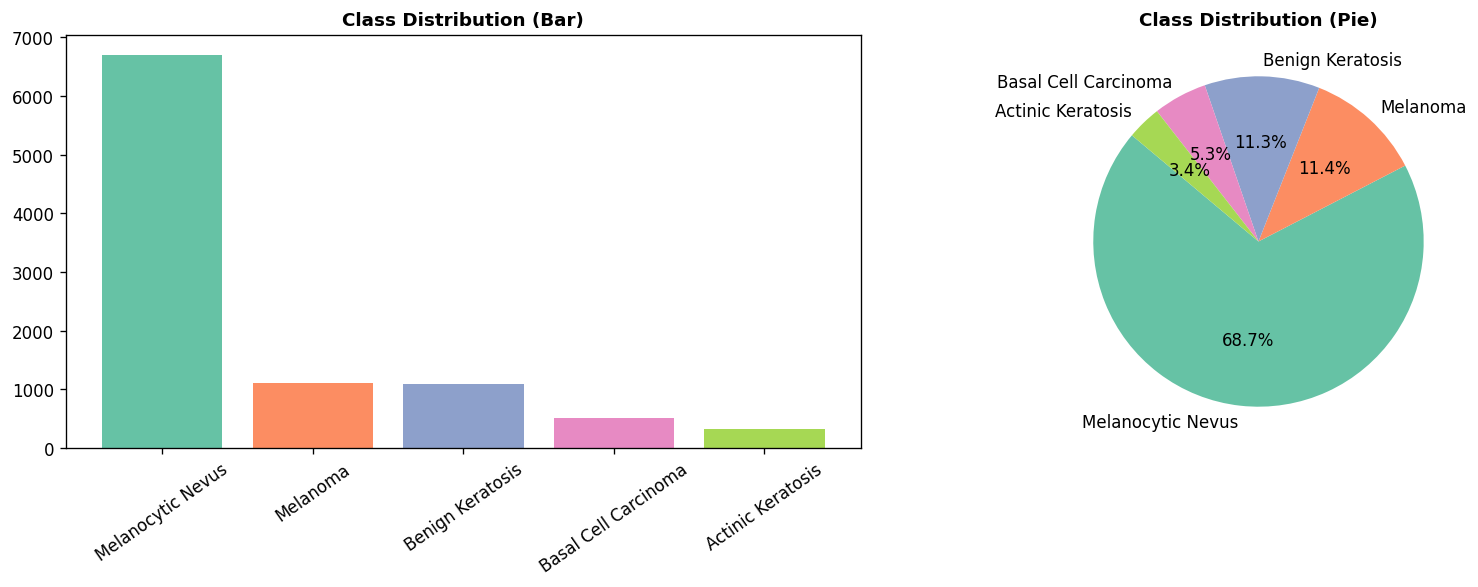

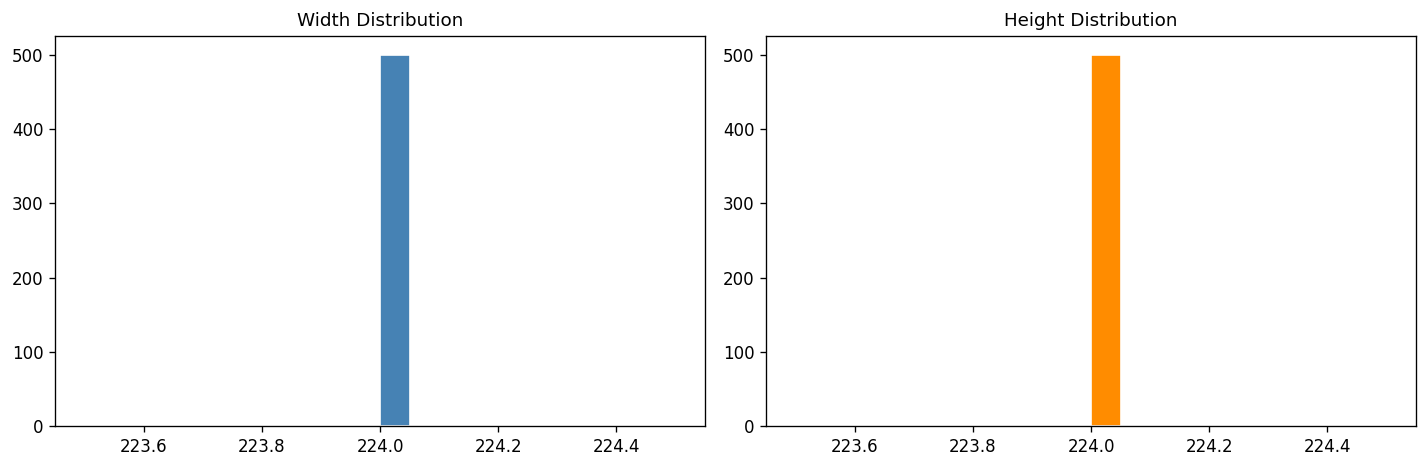

Missing values by column:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
label_clean      0
img_path         0
path_exists      0
dtype: int64
Corrupted/unreadable sampled images: 0
Resolution mean: 224.0x224.0


In [25]:
class_counts = df_valid["label_clean"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette("Set2", len(class_counts))

axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set_title("Class Distribution (Bar)", fontweight="bold")
axes[0].tick_params(axis="x", rotation=35)

axes[1].pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%", colors=colors, startangle=140)
axes[1].set_title("Class Distribution (Pie)", fontweight="bold")

plt.tight_layout()
plt.show()

sample_paths = df_valid["img_path"].sample(min(500, len(df_valid)), random_state=42)
widths, heights = [], []
for p in sample_paths:
    try:
        w, h = Image.open(p).size
        widths.append(w)
        heights.append(h)
    except Exception:
        pass

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(widths, bins=20, color="steelblue", edgecolor="white")
ax[0].set_title("Width Distribution")
ax[1].hist(heights, bins=20, color="darkorange", edgecolor="white")
ax[1].set_title("Height Distribution")
plt.tight_layout()
plt.show()

print("Missing values by column:")
print(df_valid.isnull().sum())

corrupted = []
for p in df_valid["img_path"].sample(min(300, len(df_valid)), random_state=1):
    img = cv2.imread(p)
    if img is None:
        corrupted.append(p)

print(f"Corrupted/unreadable sampled images: {len(corrupted)}")
print(f"Resolution mean: {np.mean(widths):.1f}x{np.mean(heights):.1f}")

## 6) Stratified Split (Train/Validation/Test) with Minimum 200 Images

In [26]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit

# Encode labels
le = LabelEncoder()
df_valid["label_enc"] = le.fit_transform(df_valid["label_clean"])

if len(df_valid) < 200:
    raise ValueError(f"Dataset has {len(df_valid)} valid images; minimum required is 200.")

# -----------------------------
# Split using lesion_id (NO LEAKAGE)
# -----------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss.split(df_valid, groups=df_valid["lesion_id"]))

df_train_val = df_valid.iloc[train_val_idx].reset_index(drop=True)
df_test = df_valid.iloc[test_idx].reset_index(drop=True)

# Second split: train / validation
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(gss_val.split(df_train_val, groups=df_train_val["lesion_id"]))

df_train = df_train_val.iloc[train_idx].reset_index(drop=True)
df_val = df_train_val.iloc[val_idx].reset_index(drop=True)

# -----------------------------
# Info
# -----------------------------
num_classes = len(le.classes_)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print(f"Number of classes: {num_classes}")

# Optional: check class distribution
print("\nTrain distribution:")
print(df_train["label_clean"].value_counts())

print("\nValidation distribution:")
print(df_val["label_clean"].value_counts())

print("\nTest distribution:")
print(df_test["label_clean"].value_counts())

Train: 7044 | Val: 1237 | Test: 1477
Number of classes: 5

Train distribution:
label_clean
Melanocytic Nevus       4872
Benign Keratosis         780
Melanoma                 776
Basal Cell Carcinoma     389
Actinic Keratosis        227
Name: count, dtype: int64

Validation distribution:
label_clean
Melanocytic Nevus       826
Melanoma                159
Benign Keratosis        149
Basal Cell Carcinoma     55
Actinic Keratosis        48
Name: count, dtype: int64

Test distribution:
label_clean
Melanocytic Nevus       1007
Melanoma                 178
Benign Keratosis         170
Basal Cell Carcinoma      70
Actinic Keratosis         52
Name: count, dtype: int64


In [27]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

# ─────────────────────────────────────────────
# 1. Classes + counts
# ─────────────────────────────────────────────
classes = np.unique(df_train["label_enc"])
counts = df_train["label_enc"].value_counts().sort_index().values.astype(float)

# ─────────────────────────────────────────────
# 2. Balanced class weights (correct baseline)
# ─────────────────────────────────────────────
raw_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df_train["label_enc"]
)

# ─────────────────────────────────────────────
# 3. Stabilized weighting (IMPORTANT FIX)
#    - mild smoothing only
#    - avoids extreme domination
# ─────────────────────────────────────────────
beta = 0.999   # stronger smoothing than 0.99 (better for medical imbalance)

effective_num = (1.0 - np.power(beta, counts)) / (1.0 - beta)
smooth_weights = 1.0 / (effective_num + 1e-8)

# normalize so mean = 1 (keeps model stable)
smooth_weights = smooth_weights / smooth_weights.mean()

# ─────────────────────────────────────────────
# 4. Optional clipping (prevents explosion)
# ─────────────────────────────────────────────
MAX_WEIGHT = 8.0
smooth_weights = np.clip(smooth_weights, 0, MAX_WEIGHT)

# ─────────────────────────────────────────────
# 5. Final outputs
# ─────────────────────────────────────────────
class_weights_dict = dict(zip(classes, smooth_weights))
class_weights_tensor = torch.tensor(smooth_weights, dtype=torch.float32)

# ─────────────────────────────────────────────
# 6. Label map (safe version)
# ─────────────────────────────────────────────
label_map = dict(zip(classes, df_train["label_clean"].astype(str).unique()))

# ─────────────────────────────────────────────
# 7. Display summary
# ─────────────────────────────────────────────
print(f"{'Enc':>3}  {'Class':<25} {'Count':>6}  {'Raw W':>7}  {'Final W':>7}")
print("─" * 60)

for i, enc in enumerate(classes):
    name = label_map.get(enc, str(enc))
    print(f"{enc:>3}  {name:<25} {int(counts[i]):>6}  {raw_weights[i]:>7.3f}  {smooth_weights[i]:>7.3f}")

print("\nclass_weights_dict:")
print(class_weights_dict)

print("\nclass_weights_tensor:")
print(class_weights_tensor)

Enc  Class                      Count    Raw W  Final W
────────────────────────────────────────────────────────────
  0  Benign Keratosis             227    6.206    1.933
  1  Melanocytic Nevus            389    3.622    1.218
  2  Melanoma                     780    1.806    0.725
  3  Basal Cell Carcinoma        4872    0.289    0.396
  4  Actinic Keratosis            776    1.815    0.727

class_weights_dict:
{np.int64(0): np.float64(1.9333296826232496), np.int64(1): np.float64(1.2183528263625811), np.int64(2): np.float64(0.7250161315696917), np.int64(3): np.float64(0.3958178636393322), np.int64(4): np.float64(0.7274834958051445)}

class_weights_tensor:
tensor([1.9333, 1.2184, 0.7250, 0.3958, 0.7275])


In [28]:
print(np.unique(df_train["label_enc"]))
print(df_train["label_enc"].value_counts().sort_index())
print(label_map)

[0 1 2 3 4]
label_enc
0     227
1     389
2     780
3    4872
4     776
Name: count, dtype: int64
{np.int64(0): 'Benign Keratosis', np.int64(1): 'Melanocytic Nevus', np.int64(2): 'Melanoma', np.int64(3): 'Basal Cell Carcinoma', np.int64(4): 'Actinic Keratosis'}


## 7) Reusable Image I/O and Utility Functions

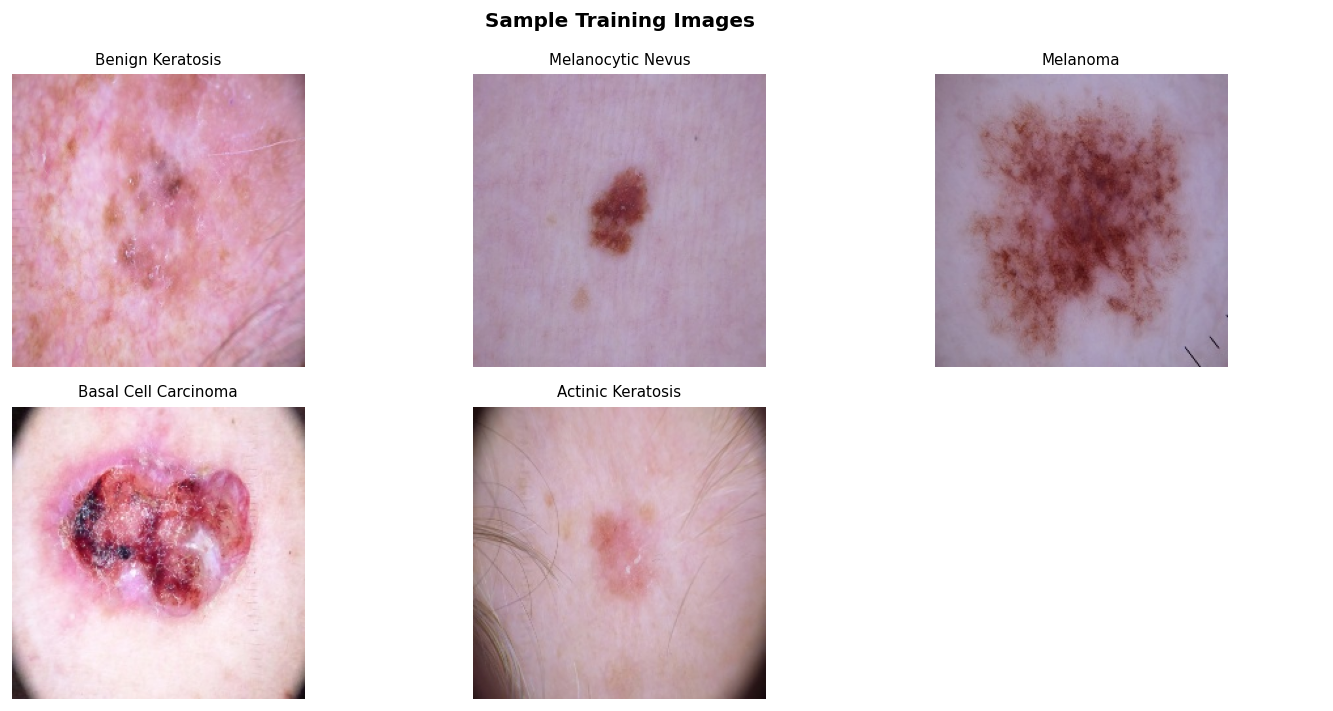

In [30]:
IMG_SIZE = (224, 224)

def load_image(path, size=IMG_SIZE):
    img = cv2.imread(str(path))
    if img is None:
        return np.zeros((*size, 3), dtype=np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, size)

def normalise(img):
    return img.astype(np.float32) / 255.0

def show_images(images, titles, ncols=4, figsize=(16, 8), suptitle=None):
    n = len(images)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for i, ax in enumerate(axes):
        if i < n:
            im = images[i]
            if getattr(im, "ndim", 0) == 2:
                ax.imshow(im, cmap="gray")
            else:
                ax.imshow(im)
            ax.set_title(titles[i], fontsize=9)
            ax.axis("off")
        else:
            ax.axis("off")

    if suptitle:
        plt.suptitle(suptitle, fontweight="bold")
    plt.tight_layout()
    plt.show()

def safe_savefig(name):
    out = FIG_DIR / f"{name}.png"
    plt.savefig(out, bbox_inches="tight")
    print(f"Saved figure: {out}")

# -----------------------------
# Sample images (random, better than head)
# -----------------------------
sample_df = df_train.groupby("label_clean").head(1)

sample_imgs = [load_image(p) for p in sample_df["img_path"]]
sample_labels = sample_df["label_clean"].tolist()

show_images(
    sample_imgs,
    sample_labels,
    ncols=3,
    figsize=(12, 6),
    suptitle="Sample Training Images"
)

# -----------------------------
# Load two images for processing
# -----------------------------
img1 = load_image(sample_df.iloc[0]["img_path"])
img2 = load_image(sample_df.iloc[1]["img_path"])

img1_gray = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

## 8) Image Preprocessing: Gaussian and Median Filtering

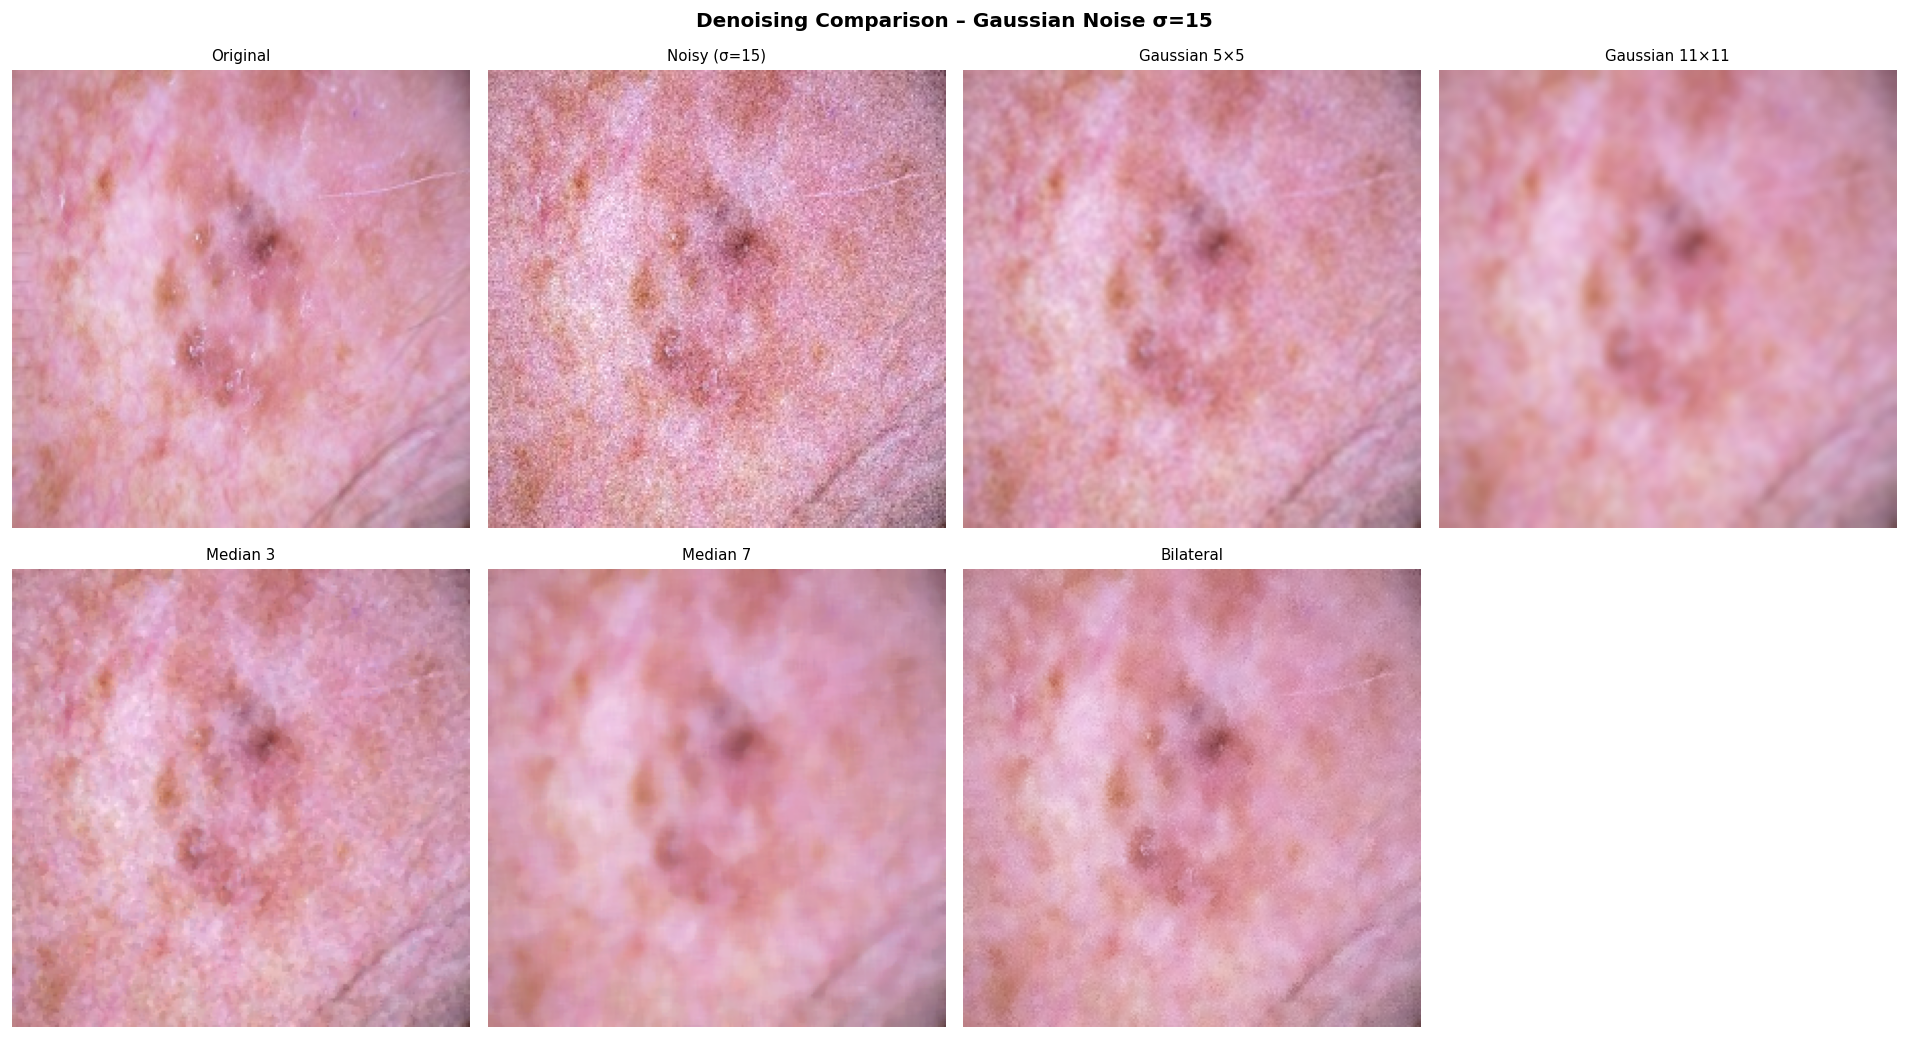

In [31]:
img_ref = img1.copy()

# Reproducible synthetic noise (luminance-like to avoid color artifacts)
noise_sigma = 15
np.random.seed(42)  # ✅ Fix 2: reproducibility

noise_2d = np.random.normal(0, noise_sigma, img_ref.shape[:2])         
noise_3c = np.repeat(noise_2d[:, :, None], 3, axis=2)
img_noisy = np.clip(img_ref.astype(np.float64) + noise_3c, 0, 255).astype(np.uint8)

# Filtering candidates
img_g5        = cv2.GaussianBlur(img_noisy, (5, 5),   sigmaX=1.0)      
img_g11       = cv2.GaussianBlur(img_noisy, (11, 11), sigmaX=2.0)     
img_m3        = cv2.medianBlur(img_noisy, 3)
img_m7        = cv2.medianBlur(img_noisy, 7)
img_bilateral = cv2.bilateralFilter(img_noisy, d=9, sigmaColor=75, sigmaSpace=75)

show_images(
    [img_ref, img_noisy, img_g5, img_g11, img_m3, img_m7, img_bilateral],
    [
        "Original",
        f"Noisy (σ={noise_sigma})",
        "Gaussian 5×5",
        "Gaussian 11×11",
        "Median 3",
        "Median 7",
        "Bilateral",
    ],
    ncols=4,
    figsize=(16, 9),
    suptitle=f"Denoising Comparison – Gaussian Noise σ={noise_sigma}",
)

## 9) Filtering Evaluation: Visual Panels + MSE/PSNR Metrics

           Method      MSE    PSNR
1    Gaussian 5x5   28.425  33.594
2  Gaussian 11x11   29.050  33.499
4        Median 7   36.396  32.520
5       Bilateral   41.006  32.002
3        Median 3   48.471  31.276
0           Noisy  223.693  24.634


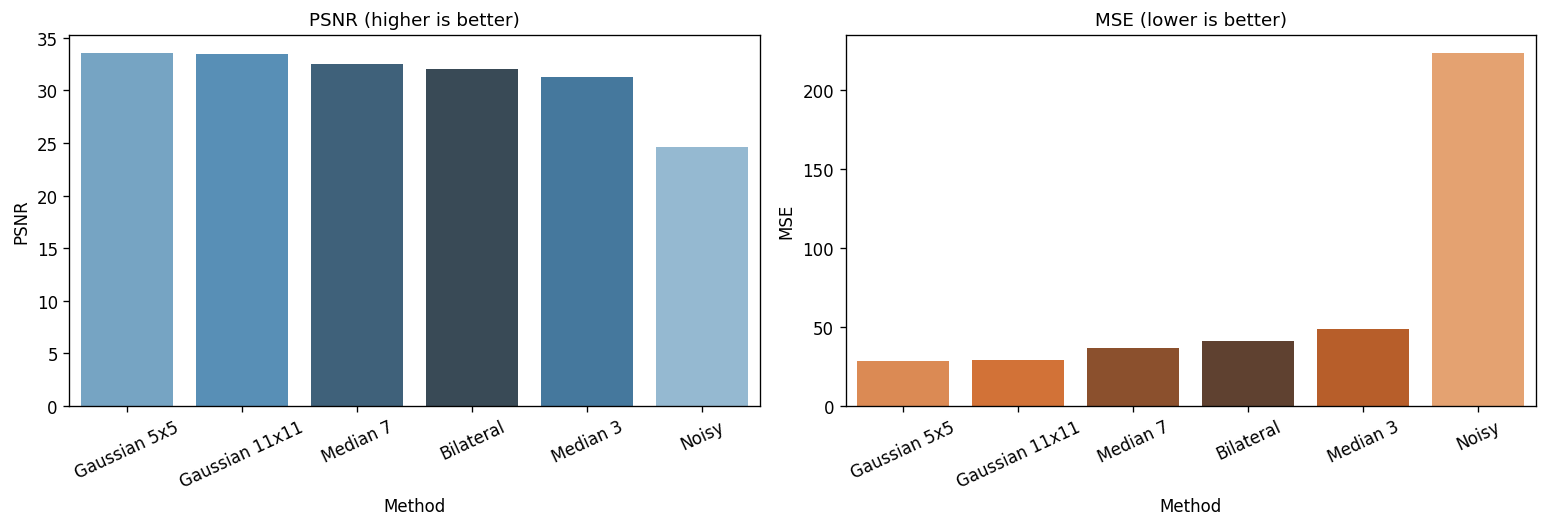

In [32]:
from skimage.metrics import mean_squared_error as mse, peak_signal_noise_ratio as psnr 

def metric_entry(name, original, filtered):
    return {
        "Method": name,
        "MSE":  float(mse(original, filtered)),
        "PSNR": float(psnr(original, filtered, data_range=255)),
    }

filter_metrics = pd.DataFrame([
    metric_entry("Noisy",          img_ref, img_noisy),
    metric_entry("Gaussian 5x5",   img_ref, img_g5),
    metric_entry("Gaussian 11x11", img_ref, img_g11),
    metric_entry("Median 3",       img_ref, img_m3),
    metric_entry("Median 7",       img_ref, img_m7),
    metric_entry("Bilateral",      img_ref, img_bilateral),
])

print(filter_metrics.round(3).sort_values("PSNR", ascending=False))

order = filter_metrics.sort_values("PSNR", ascending=False)["Method"].tolist()  

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=filter_metrics, x="Method", y="PSNR", ax=axes[0],        
            order=order, hue="Method", palette="Blues_d", legend=False)
axes[0].set_title("PSNR (higher is better)")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=filter_metrics, x="Method", y="MSE",  ax=axes[1],      
            order=order, hue="Method", palette="Oranges_d", legend=False)
axes[1].set_title("MSE (lower is better)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## 10) Harris Corner Detection and Threshold Sensitivity Analysis

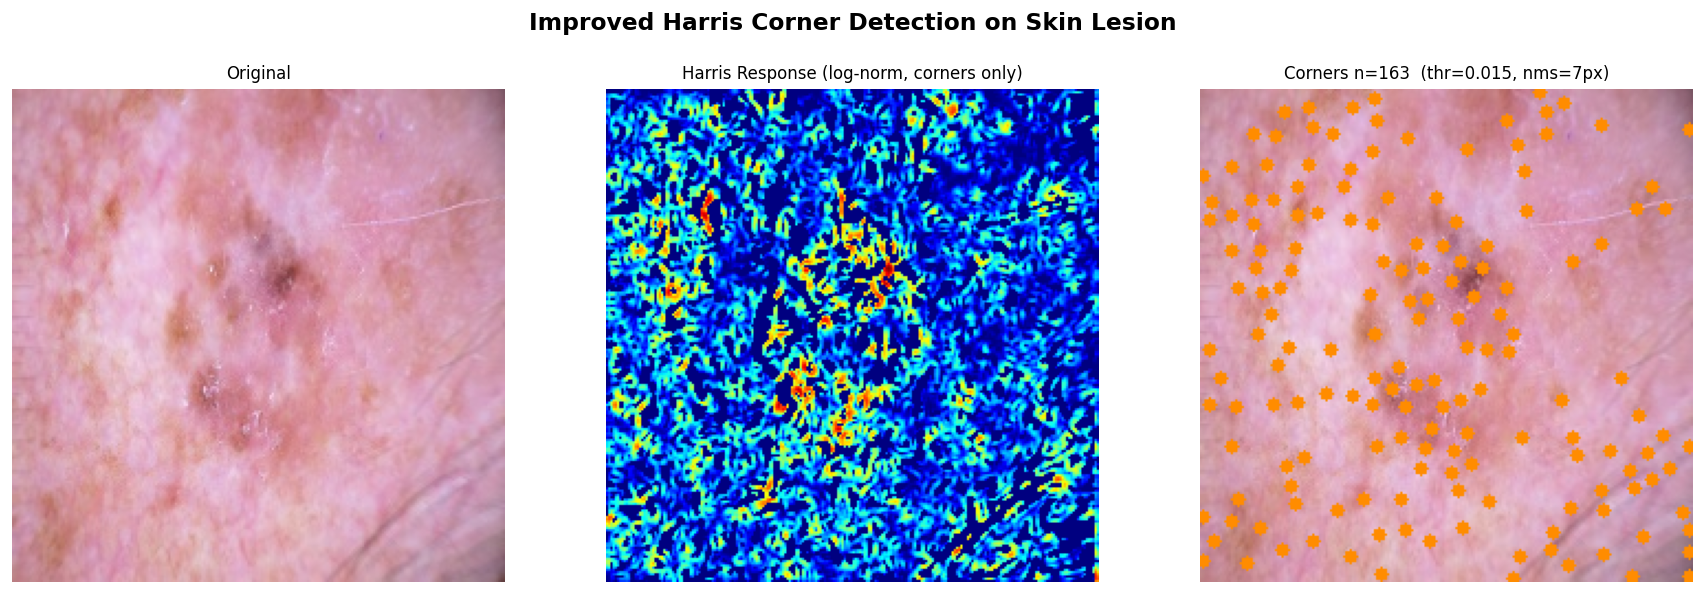

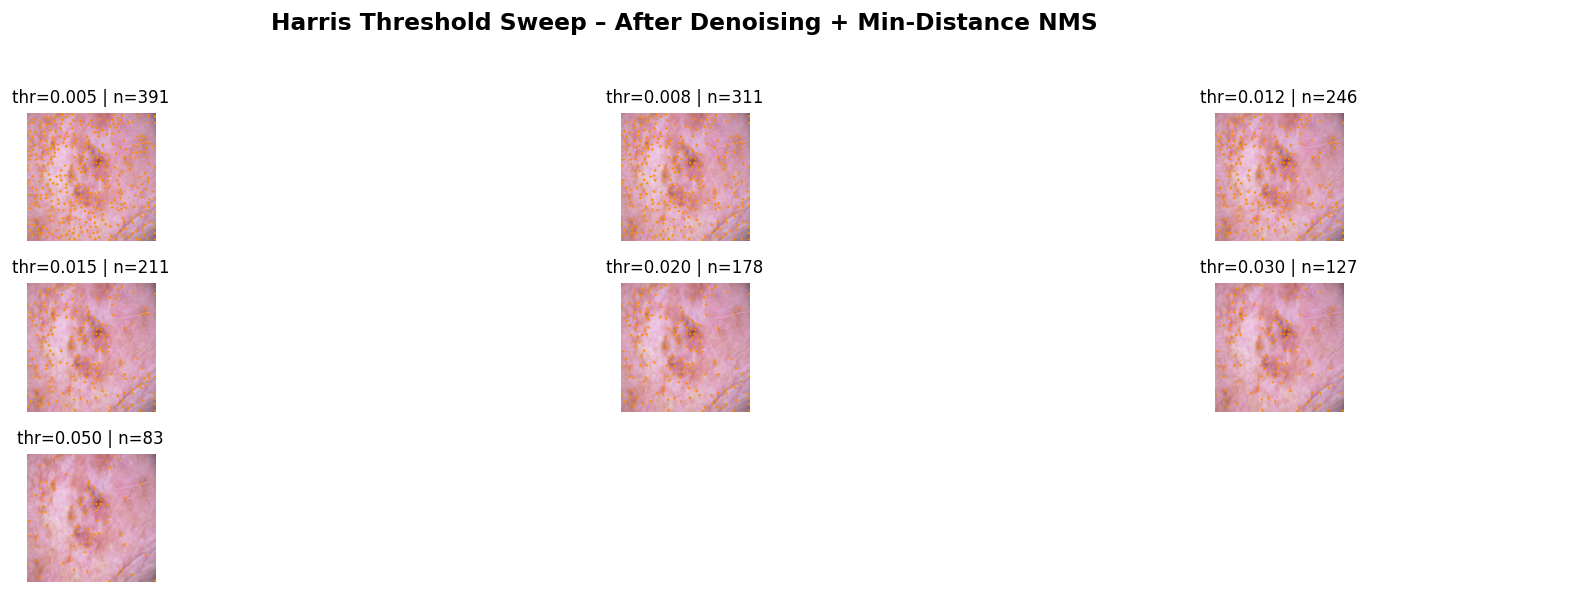

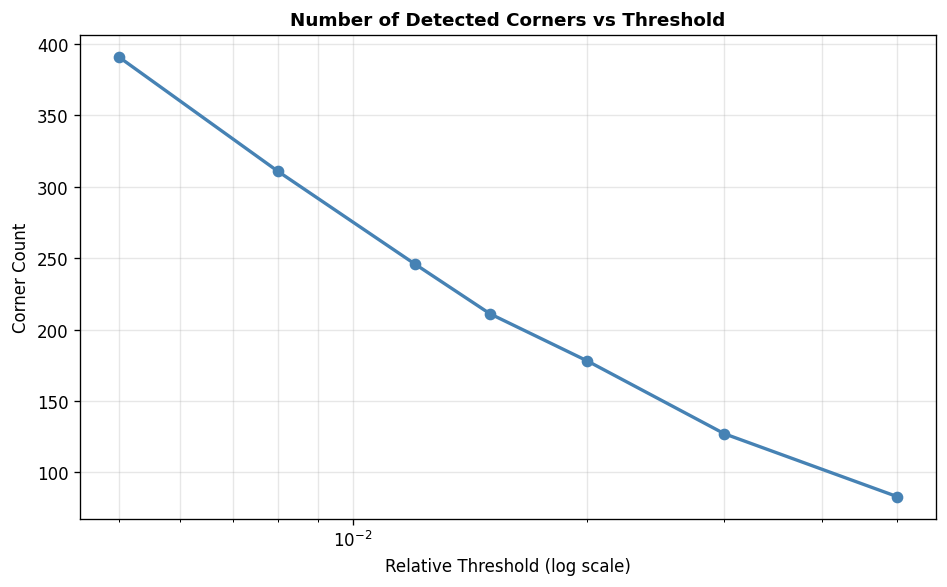

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ================================================================
#  Helper: show_images
# ================================================================
def show_images(images, titles=None, ncols=3, figsize=(15, 5), suptitle=None):
    n = len(images)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if suptitle:
        fig.suptitle(suptitle, fontsize=14, fontweight='bold')
    if nrows == 1 and ncols == 1:
        axes = np.array([axes])
    else:
        axes = np.array(axes).flatten()
    for i, ax in enumerate(axes):
        if i < n:
            img = images[i]
            ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
            if titles and i < len(titles):
                ax.set_title(titles[i], fontsize=10)
        ax.axis('off')
    # FIX 5: rect leaves headroom so suptitle is never clipped
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# ================================================================
#  FIX 1: Separate response computation from thresholding
#          so the sweep reuses one response map instead of
#          rerunning GaussianBlur + cornerHarris 7 times.
# ================================================================
def compute_harris_response(img_gray, block_size=3, k_size=3, k=0.04):
    """
    Compute and return the raw Harris response map.
    Call once; pass the result to apply_harris_threshold().
    """
    # FIX 7: explicit sigma instead of sigmaX=0
    denoised = cv2.GaussianBlur(img_gray, (5, 5), sigmaX=1.4)
    gray_f   = np.float32(denoised)
    return cv2.cornerHarris(gray_f, block_size, k_size, k)


def apply_harris_threshold(response, threshold=0.015, min_distance=7):
    """
    Threshold the response map + apply greedy minimum-distance NMS.

    Parameters
    ----------
    response     : raw float32 Harris response from compute_harris_response()
    threshold    : fraction of response.max() used as cutoff
    min_distance : minimum pixel radius between any two retained corners
                   (FIX 2: prevents dense corner clusters)
    """
    # Step 1 — basic 3×3 local-maxima suppression
    resp_dilated = cv2.dilate(response, None)
    thresh_val   = threshold * response.max()
    candidate_mask = (response == resp_dilated) & (response > thresh_val)

    if min_distance <= 1:
        return candidate_mask

    # Step 2 — greedy minimum-distance NMS
    # Sort candidates by descending response strength
    ys, xs       = np.where(candidate_mask)
    strengths    = response[ys, xs]
    order        = np.argsort(-strengths)          # strongest first
    ys, xs       = ys[order], xs[order]

    H, W         = response.shape
    suppressed   = np.zeros((H, W), dtype=bool)
    final_mask   = np.zeros((H, W), dtype=bool)

    for y, x in zip(ys.tolist(), xs.tolist()):
        if suppressed[y, x]:
            continue
        final_mask[y, x] = True
        # Suppress all neighbours within min_distance (square approximation — fast)
        y0 = max(0, y - min_distance)
        y1 = min(H, y + min_distance + 1)
        x0 = max(0, x - min_distance)
        x1 = min(W, x + min_distance + 1)
        suppressed[y0:y1, x0:x1] = True

    return final_mask


def draw_corners(img_rgb, mask, color=(255, 140, 0), radius=3,
                 max_points=3000, seed=42):
    """
    Draw detected corners onto a copy of img_rgb.
    FIX 4: unified colour (orange) for both single run and sweep.
    FIX 6: deterministic subsampling via fixed seed.
    """
    out      = img_rgb.copy()
    ys, xs   = np.where(mask)
    n        = len(xs)

    if n > max_points:
        rng  = np.random.default_rng(seed)          # FIX 6: reproducible
        idx  = rng.choice(n, max_points, replace=False)
        xs, ys = xs[idx], ys[idx]
        n    = max_points

    for y, x in zip(ys.tolist(), xs.tolist()):      # .tolist() avoids numpy int overhead
        cv2.circle(out, (x, y), radius, color, -1)

    return out, n


# ================================================================
#  Main — compute response ONCE, reuse everywhere
# ================================================================
h_resp = compute_harris_response(img1_gray)         # FIX 1: single computation

# Apply threshold + proper NMS
h_mask = apply_harris_threshold(h_resp, threshold=0.015, min_distance=7)

# --- FIX 3: log-normalise positive response only for visualisation ---
# Negative Harris values = edges (not corners); clipping them out
# focuses the colormap on actual corner strength.
h_resp_pos = np.clip(h_resp, 0, None)
h_resp_log = np.log1p(h_resp_pos)                   # log1p avoids log(0)
h_resp_vis = cv2.normalize(
    h_resp_log, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)
h_resp_vis = cv2.applyColorMap(h_resp_vis, cv2.COLORMAP_JET)
h_resp_vis = cv2.cvtColor(h_resp_vis, cv2.COLOR_BGR2RGB)

h_vis, n_c = draw_corners(img1, h_mask, radius=3)

show_images(
    [img1, h_resp_vis, h_vis],
    [
        "Original",
        "Harris Response (log-norm, corners only)",
        f"Corners n={n_c}  (thr=0.015, nms=7px)",
    ],
    ncols=3,
    figsize=(15, 5),
    suptitle="Improved Harris Corner Detection on Skin Lesion",
)


# ================================================================
#  Threshold Sweep — safe, no accumulation across re-runs
# ================================================================
thr_values = [0.005, 0.008, 0.012, 0.015, 0.02, 0.03, 0.05]

# ✅ Build everything in one expression — no persistent mutable state
sweep_results = [
    (*draw_corners(img1, apply_harris_threshold(h_resp, threshold=t, min_distance=5), radius=2), t)
    for t in thr_values
]

vis_images = [r[0] for r in sweep_results]
counts     = [r[1] for r in sweep_results]
titles     = [f"thr={r[2]:.3f} | n={r[1]}" for r in sweep_results]

show_images(
    vis_images, titles,
    ncols=3,
    suptitle="Harris Threshold Sweep – After Denoising + Min-Distance NMS",
)

plt.figure(figsize=(8, 5))
plt.plot(thr_values, counts, marker='o', linewidth=2, color='steelblue')
plt.xscale('log')
plt.title("Number of Detected Corners vs Threshold", fontweight='bold')
plt.xlabel("Relative Threshold (log scale)")
plt.ylabel("Corner Count")
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 11) Multi-Scale Analysis: Gaussian/Laplacian Pyramids + Scale-Space Blob Detection

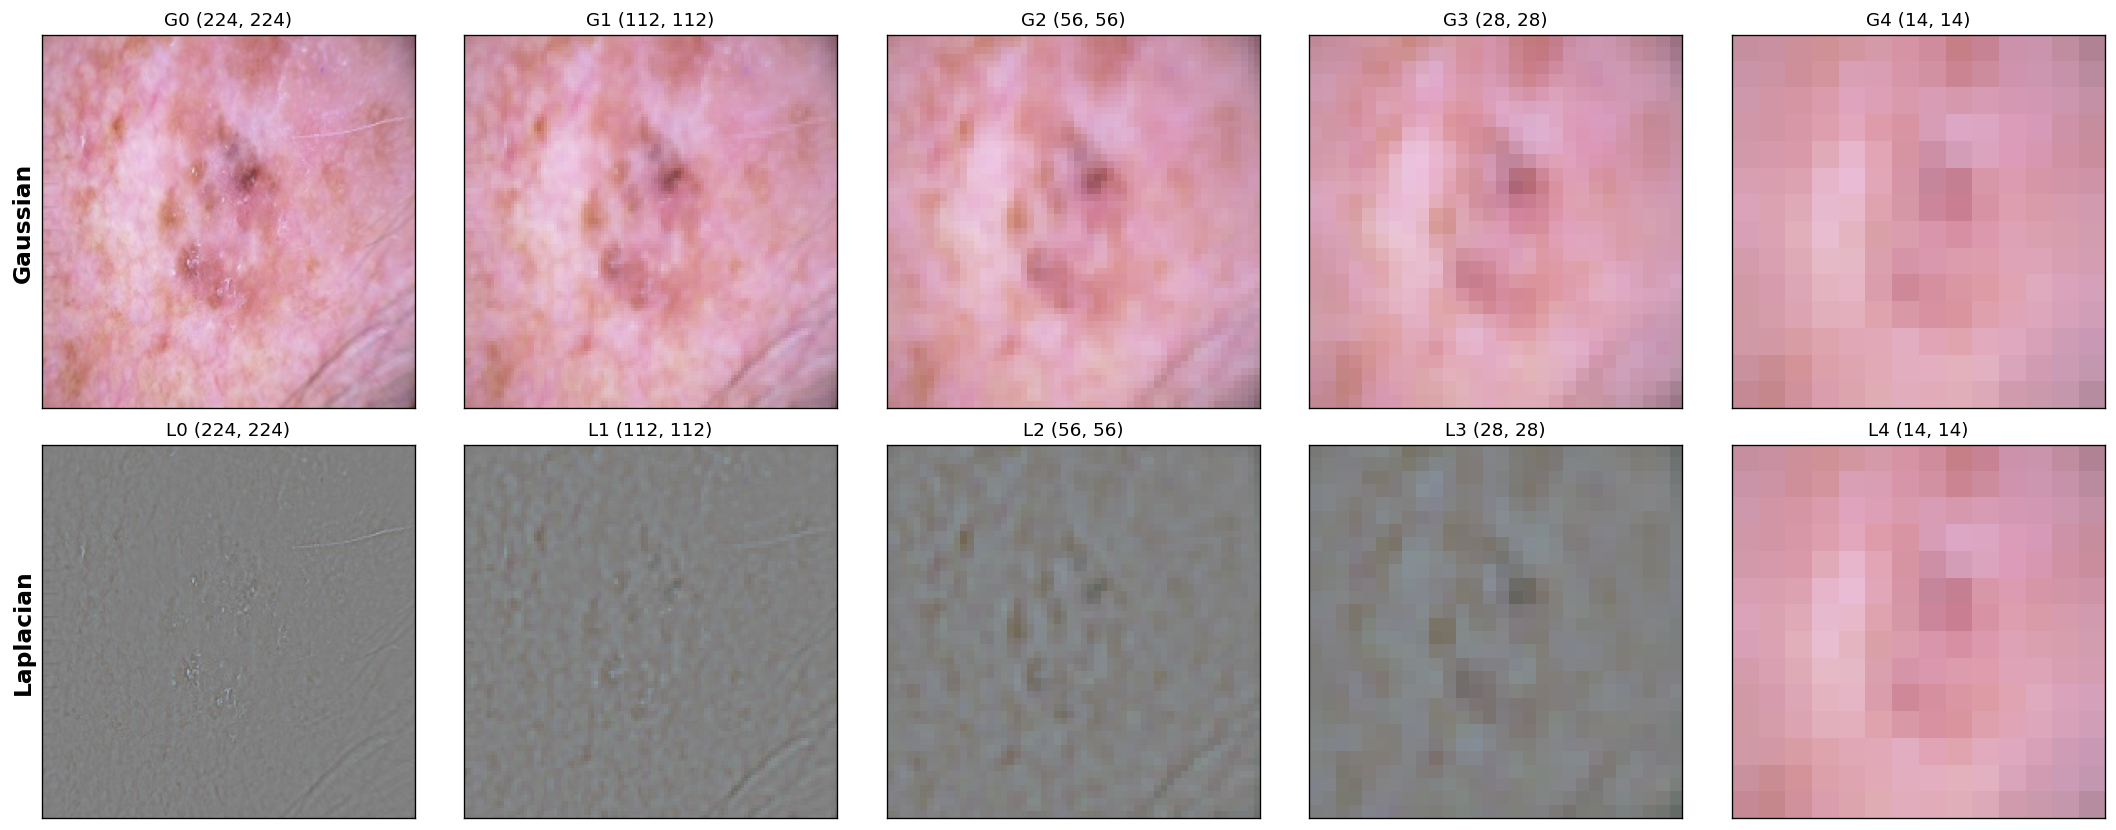

Scale | BlobCount | Shape
(0, 26, (224, 224))
(1, 3, (112, 112))
(2, 2, (56, 56))
(3, 1, (28, 28))
(4, 0, (14, 14))


In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import blob_log  # <-- Added missing import

def build_gaussian_pyramid(img, levels=5):
    pyr = [img]
    cur = img.copy()
    for _ in range(levels - 1):
        cur = cv2.pyrDown(cur)
        pyr.append(cur)
    return pyr

def build_laplacian_pyramid(gauss):
    lap = []
    for i in range(len(gauss) - 1):
        up = cv2.pyrUp(gauss[i + 1], dstsize=(gauss[i].shape[1], gauss[i].shape[0]))
        
        # FIX 1: Convert to int16 to prevent clipping negative values to 0!
        # Laplacian requires both positive and negative edge responses.
        diff = cv2.subtract(gauss[i].astype(np.int16), up.astype(np.int16))
        lap.append(diff)
        
    # The top level of Laplacian is simply the smallest Gaussian image
    lap.append(gauss[-1])
    return lap

# ==========================================
# Assuming 'img1' is already defined in your notebook
# img1 = cv2.imread('lesion.jpg')[..., ::-1] 
# ==========================================

LEVELS = 5
g_pyr = build_gaussian_pyramid(img1, LEVELS)
l_pyr = build_laplacian_pyramid(g_pyr)

fig, axes = plt.subplots(2, LEVELS, figsize=(18, 7))
for i in range(LEVELS):
    # Gaussian Display
    axes[0, i].imshow(g_pyr[i])
    axes[0, i].set_title(f"G{i} {g_pyr[i].shape[:2]}")
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([]) # Better than axis('off') to keep ylabels

    # Laplacian Display
    if i == LEVELS - 1:
        # FIX 2: Do not normalize the final level, it's just the base image
        l_disp = l_pyr[i].astype(np.uint8)
    else:
        # FIX 3: Standard zero-centered visualization for signed Laplacian data
        # Shift 0 to 128 (mid-gray), then clip to uint8 range
        l_disp = np.clip(l_pyr[i] + 128, 0, 255).astype(np.uint8)

    axes[1, i].imshow(l_disp)
    axes[1, i].set_title(f"L{i} {l_pyr[i].shape[:2]}")
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])

axes[0, 0].set_ylabel("Gaussian", fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel("Laplacian", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# Object response at multiple scales using LoG
# ==========================================
blob_counts = []
for i, g in enumerate(g_pyr):
    gray = cv2.cvtColor(g, cv2.COLOR_RGB2GRAY) / 255.0
    blobs = blob_log(gray, min_sigma=1, max_sigma=8, num_sigma=8, threshold=0.06)
    blob_counts.append((i, len(blobs), g.shape[:2]))

print("Scale | BlobCount | Shape")
for row in blob_counts:
    print(row)

## 12) SIFT Feature Extraction, Matching, and Matching Accuracy

Keypoints A: 111,  Keypoints B: 118


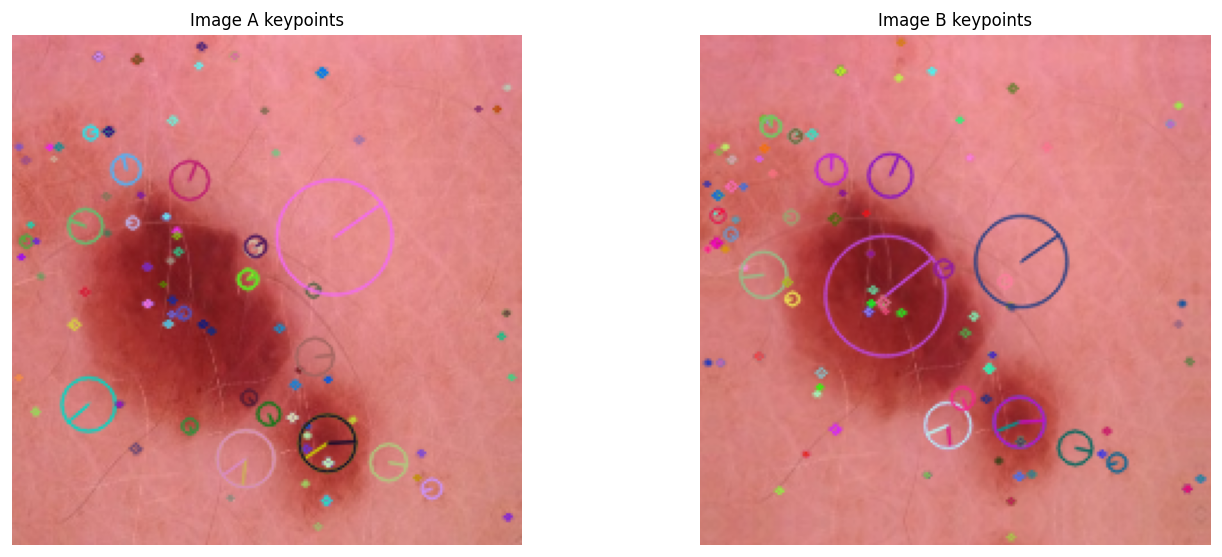

Raw KNN pairs:        111
Lowe's good matches:  63   (acceptance rate: 56.8%)
RANSAC inliers:       59   (geometric accuracy: 93.7%)


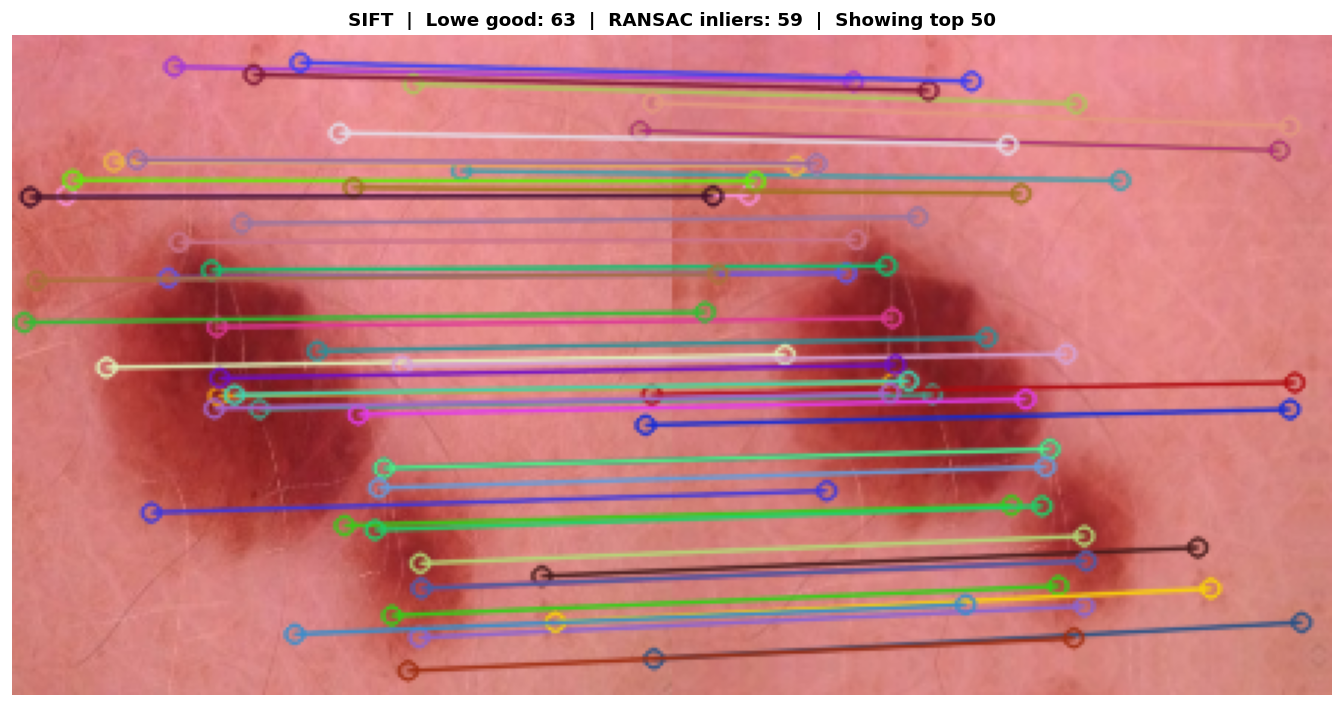

In [35]:
if not hasattr(cv2, "SIFT_create"):
    raise RuntimeError("SIFT unavailable. Install opencv-contrib-python.")

# --- Step 1: Load + create a MEANINGFUL synthetic pair ---
sample = df_valid.sample(1, random_state=42)
pa     = sample["img_path"].values[0]
imgA   = load_image(pa)
h, w   = imgA.shape[:2]

# FIX: use a perspective warp instead of pure rotation+scale.
# Perspective introduces non-uniform distortion that:
#   (a) produces non-horizontal, varied match lines
#   (b) gives RANSAC real outliers to reject (homography ≠ affine)
src_pts = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
dst_pts = np.float32([
    [w * 0.04,  h * 0.02],   # top-left shifts right+down
    [w * 0.96,  h * 0.05],   # top-right shifts left+down
    [w * 0.98,  h * 0.94],   # bottom-right minimal shift
    [w * 0.02,  h * 0.96],   # bottom-left minimal shift
])
M    = cv2.getPerspectiveTransform(src_pts, dst_pts)
imgB = cv2.warpPerspective(imgA, M, (w, h),
                           flags=cv2.INTER_LINEAR,
                           borderMode=cv2.BORDER_REFLECT)

gA = cv2.cvtColor(imgA, cv2.COLOR_RGB2GRAY)
gB = cv2.cvtColor(imgB, cv2.COLOR_RGB2GRAY)

# CLAHE for better keypoint density on low-contrast skin
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
gA_eq = clahe.apply(gA)
gB_eq = clahe.apply(gB)

# --- Step 2: Detect SIFT ---
sift      = cv2.SIFT_create(nfeatures=800)
kp1, des1 = sift.detectAndCompute(gA_eq, None)
kp2, des2 = sift.detectAndCompute(gB_eq, None)
print(f"Keypoints A: {len(kp1)},  Keypoints B: {len(kp2)}")

imgA_kp = cv2.drawKeypoints(imgA, kp1, None,
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
imgB_kp = cv2.drawKeypoints(imgB, kp2, None,
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
show_images([imgA_kp, imgB_kp],
            ["Image A keypoints", "Image B keypoints"],
            ncols=2, figsize=(12, 5))

# --- Step 3: Match ---
bf           = cv2.BFMatcher(cv2.NORM_L2)
raw_matches  = []
good_matches = []

if (des1 is not None and des2 is not None
        and len(des1) >= 2 and len(des2) >= 2):

    raw_matches = bf.knnMatch(des1, des2, k=2)

    for pair in raw_matches:
        if len(pair) == 2:
            m, n = pair
            if m.distance < 0.75 * n.distance:   # standard Lowe's ratio
                good_matches.append(m)

    if not good_matches:
        print("⚠️ No good matches with KNN → fallback to direct matching")
        raw_matches  = sorted(bf.match(des1, des2), key=lambda x: x.distance)
        good_matches = raw_matches[:50]

n_raw  = len(raw_matches)
n_good = len(good_matches)

# --- Step 4: RANSAC geometric verification ---
inlier_matches = []
H_matrix       = None

if len(good_matches) >= 4:
    src_kp = np.float32(
        [kp1[m.queryIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)
    dst_kp = np.float32(
        [kp2[m.trainIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)

    H_matrix, inlier_mask = cv2.findHomography(
        src_kp, dst_kp,
        cv2.RANSAC,
        ransacReprojThreshold=3.0   # tighter = more meaningful rejection
    )
    if inlier_mask is not None:
        inlier_matches = [
            m for m, flag in zip(good_matches, inlier_mask.ravel()) if flag
        ]

lowe_rate = n_good / max(n_raw, 1)
geom_acc  = len(inlier_matches) / max(n_good, 1)

print(f"Raw KNN pairs:        {n_raw}")
print(f"Lowe's good matches:  {n_good}   (acceptance rate: {lowe_rate*100:.1f}%)")
print(f"RANSAC inliers:       {len(inlier_matches)}   (geometric accuracy: {geom_acc*100:.1f}%)")

if geom_acc > 0.98:
    print("⚠️  100% inlier rate — warp may still be too clean to stress-test RANSAC.")

# --- Step 5: Visualize top-50 inliers only for readability ---
display_matches = (inlier_matches if inlier_matches else good_matches)
# FIX: sort by distance and cap at 50 — 404 lines is unreadable
display_matches = sorted(display_matches, key=lambda m: m.distance)[:50]

img_match = cv2.drawMatches(
    imgA, kp1, imgB, kp2,
    display_matches, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)
plt.figure(figsize=(16, 6))
plt.imshow(img_match)
plt.title(
    f"SIFT  |  Lowe good: {n_good}  |  RANSAC inliers: {len(inlier_matches)}"
    f"  |  Showing top 50",
    fontweight="bold",
)
plt.axis("off")
plt.tight_layout()
plt.show()

## 13) Segmentation Methods: Otsu, K-Means, and Watershed

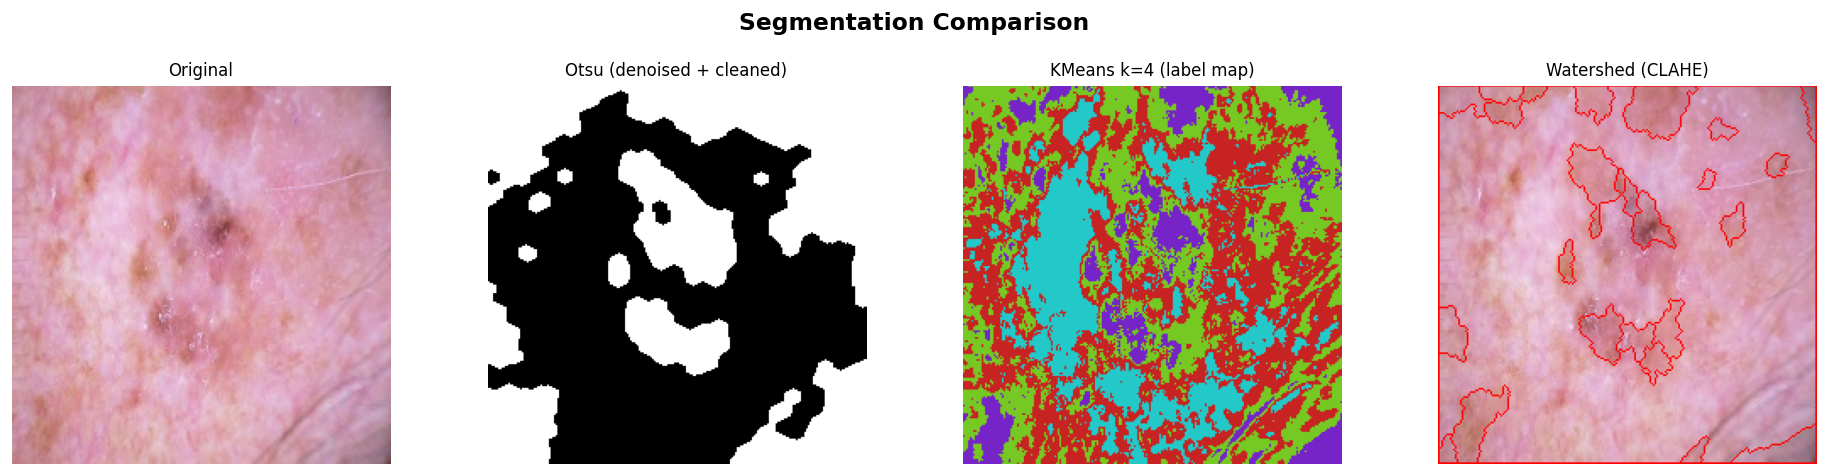

In [36]:
seg_img  = img1.copy()
seg_gray = cv2.cvtColor(seg_img, cv2.COLOR_RGB2GRAY)

# ================================================================
# Otsu — FIX 1: denoise first, FIX 2: INV polarity, FIX 3: cleanup
# ================================================================
seg_gray_blur = cv2.GaussianBlur(seg_gray, (7, 7), sigmaX=1.5)   # FIX 1
_, otsu_mask  = cv2.threshold(
    seg_gray_blur, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU    # FIX 2: lesion → white
)
kernel_otsu = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
otsu_mask   = cv2.morphologyEx(otsu_mask, cv2.MORPH_OPEN,  kernel_otsu, iterations=2)
otsu_mask   = cv2.morphologyEx(otsu_mask, cv2.MORPH_CLOSE, kernel_otsu, iterations=2)  # FIX 3

# ================================================================
# KMeans — FIX 4: distinct label-map colors, FIX 5: PP_CENTERS
# ================================================================
def kmeans_segment(img_rgb, k=4):
    px       = img_rgb.reshape(-1, 3).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 200, 0.1)
    _, labels, centers = cv2.kmeans(
        px, k, None, criteria, 10,
        cv2.KMEANS_PP_CENTERS    # FIX 5: stable initialization
    )
    centers   = np.uint8(centers)
    labels_2d = labels.reshape(img_rgb.shape[:2])

    # FIX 4: HSV-spaced distinct colors per cluster — not the skin-tone centers
    hue_step    = 180 // k
    label_colors = np.array([
        cv2.cvtColor(
            np.uint8([[[h * hue_step, 210, 200]]]),
            cv2.COLOR_HSV2RGB
        )[0, 0]
        for h in range(k)
    ], dtype=np.uint8)
    label_vis = label_colors[labels_2d]   # distinct color per cluster

    seg_centers = centers[labels.flatten()].reshape(img_rgb.shape)
    return seg_centers, label_vis, labels_2d, centers


# ================================================================
# Watershed — FIX 6: CLAHE+blur, FIX 7: lower sure_fg, FIX 8: ellipse kernel
# ================================================================
def watershed_segment(img_rgb):
    gray    = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # FIX 6: CLAHE boosts lesion/skin contrast before thresholding
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_eq = clahe.apply(gray)
    blurred = cv2.GaussianBlur(gray_eq, (5, 5), sigmaX=1.0)

    _, thresh = cv2.threshold(
        blurred, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))  # FIX 8
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN,  kernel, iterations=2)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    dist       = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(
        dist, 0.3 * dist.max(), 255, 0    # FIX 7: 0.3 vs 0.5 → more seeds
    )
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers         = cv2.connectedComponents(sure_fg)
    markers            = markers + 1
    markers[unknown == 255] = 0
    markers            = cv2.watershed(
        cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR), markers
    )
    result             = img_rgb.copy()
    result[markers == -1] = [255, 0, 0]
    return result, markers


# --- Run ---
_, km_label_vis, km_labels, km_centers = kmeans_segment(seg_img, k=4)
ws_img, ws_markers                     = watershed_segment(seg_img)

show_images(
    [seg_img, otsu_mask, km_label_vis, ws_img],
    ["Original", "Otsu (denoised + cleaned)", "KMeans k=4 (label map)", "Watershed (CLAHE)"],
    ncols=4,
    figsize=(16, 4),
    suptitle="Segmentation Comparison"
)

## 14) Segmentation Evaluation with IoU

Note: IoU measured against Otsu pseudo-GT (no manual annotation available)
      Method  IoU vs Otsu (pseudo-GT)
0     KMeans                   0.5145
1  Watershed                   0.3977


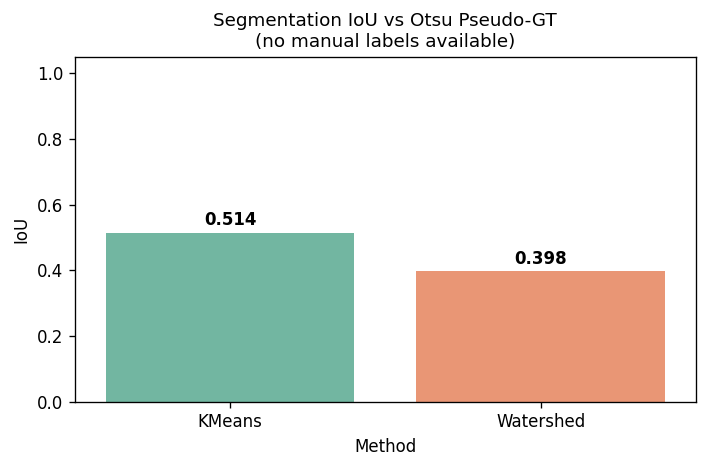

In [37]:
def compute_iou(mask_pred, mask_gt):
    pred  = mask_pred.astype(bool)
    gt    = mask_gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    # FIX: proper empty-mask handling instead of silent 1e-8 fudge
    return float(inter / union) if union > 0 else 0.0


# Pseudo-ground-truth (Otsu) — used only as reference, not as a competitor
otsu_gt = otsu_mask > 0


# ================================================================
# KMeans — FIX 2+3: evaluate ALL k clusters, pick best, no redundant flip
# ================================================================
center_gray = np.array([
    0.299 * c[0] + 0.587 * c[1] + 0.114 * c[2]
    for c in km_centers
])

best_km_iou  = -1.0
best_km_mask = None

for cluster_idx in range(len(km_centers)):          # FIX 2: all clusters
    candidate = (km_labels == cluster_idx)
    iou_normal  = compute_iou(candidate,  otsu_gt)
    iou_flipped = compute_iou(~candidate, otsu_gt)
    # Take whichever polarity scores better — FIX 3: no separate fix_polarity
    if iou_normal >= iou_flipped:
        iou, mask = iou_normal,  candidate
    else:
        iou, mask = iou_flipped, ~candidate
    if iou > best_km_iou:
        best_km_iou  = iou
        best_km_mask = mask

km_mask = best_km_mask


# ================================================================
# Watershed — FIX 4: select LARGEST foreground region, not all of them
# ================================================================
ws_mask_raw = np.zeros(ws_markers.shape, dtype=bool)

# Collect all valid segment labels (≥2, excluding background=1 and boundary=-1)
segment_labels = np.unique(ws_markers)
segment_labels = segment_labels[segment_labels >= 2]

if len(segment_labels) > 0:
    # Pick the largest segment (most likely the dominant lesion region)
    largest_label = max(
        segment_labels,
        key=lambda lbl: np.sum(ws_markers == lbl)
    )
    ws_mask_raw = (ws_markers == largest_label)

# Still allow polarity correction relative to Otsu
iou_ws_normal  = compute_iou(ws_mask_raw,  otsu_gt)
iou_ws_flipped = compute_iou(~ws_mask_raw, otsu_gt)
ws_mask = ws_mask_raw if iou_ws_normal >= iou_ws_flipped else ~ws_mask_raw


# ================================================================
# IoU table — FIX 1+5: drop circular Otsu(self), label as pseudo-GT
# ================================================================
iou_scores = pd.DataFrame({
    "Method": ["KMeans", "Watershed"],          # FIX 1: Otsu(self) removed
    "IoU vs Otsu (pseudo-GT)": [
        compute_iou(km_mask, otsu_gt),
        compute_iou(ws_mask, otsu_gt),
    ],
})
print("Note: IoU measured against Otsu pseudo-GT (no manual annotation available)")
print(iou_scores.round(4))

# ================================================================
# Chart — FIX 6: no 1.0 anchor bar compressing the scale
# ================================================================
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=iou_scores,
    x="Method",
    y="IoU vs Otsu (pseudo-GT)",
    palette="Set2",
    hue="Method",
    legend=False,
)
# Annotate exact values on bars
for bar, val in zip(ax.patches, iou_scores["IoU vs Otsu (pseudo-GT)"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

plt.ylim(0, 1.05)
plt.title("Segmentation IoU vs Otsu Pseudo-GT\n(no manual labels available)", fontsize=11)
plt.ylabel("IoU")
plt.tight_layout()
plt.show()

## 15) Feature Engineering for Classification (Histogram + HOG + Stats)

In [38]:
from skimage.feature import local_binary_pattern
from skimage.feature import graycomatrix, graycoprops
import cv2, numpy as np, pandas as pd
from skimage.feature import hog

# ── define df_work ─────────────────────────────────────────────────────────
MAX_PER_CLASS = None

if MAX_PER_CLASS is not None:
    df_work = (
        df_valid
        .groupby("label_clean", group_keys=False)
        .apply(lambda g: g.sample(min(len(g), MAX_PER_CLASS), random_state=42), include_groups=False)
        .reset_index(drop=True)
    )
else:
    df_work = df_valid.copy()

print(f"Working subset: {len(df_work)} images")
print(df_work["label_clean"].value_counts())

# ── helpers ────────────────────────────────────────────────────────────────
def lesion_mask_otsu(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if (mask > 0).mean() > 0.6:
        mask = cv2.bitwise_not(mask)
    return mask > 0

def lbp_histogram(gray, mask, P=16, R=2, n_bins=18):
    """Local Binary Pattern histogram — captures micro-texture discriminatively."""
    lbp = local_binary_pattern(gray, P=P, R=R, method="uniform")
    vals = lbp[mask] if mask.any() else lbp.ravel()
    hist, _ = np.histogram(vals, bins=n_bins, range=(0, P + 2), density=True)
    return hist

def glcm_features(gray, mask):
    """Gray-Level Co-occurrence Matrix: contrast, correlation, energy, homogeneity."""
    g = gray.copy()
    g[~mask] = 0
    g_q = (g // 4).astype(np.uint8)
    glcm = graycomatrix(
        g_q, distances=[1, 3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=64, symmetric=True, normed=True
    )
    feats = []
    for prop in ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]:
        feats.extend(graycoprops(glcm, prop).ravel().tolist())
    return feats

def color_histograms(img, mask, bins=32):
    """Histograms in RGB, HSV, and LAB colour spaces."""
    feats = []
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB).astype(np.float32)
    for space in [img.astype(np.float32), hsv, lab]:
        for ch in range(3):
            vals = space[:, :, ch][mask] if mask.any() else space[:, :, ch].ravel()
            vmin, vmax = space[:, :, ch].min(), space[:, :, ch].max() + 1e-6
            hist, _ = np.histogram(vals, bins=bins, range=(vmin, vmax), density=True)
            feats.extend(hist.tolist())
    return feats

def color_moments(img, mask):
    """Mean, std, skewness per channel in RGB + HSV + LAB."""
    from scipy.stats import skew
    feats = []
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB).astype(np.float32)
    for space in [img.astype(np.float32), hsv, lab]:
        for ch in range(3):
            vals = space[:, :, ch][mask] if mask.any() else space[:, :, ch].ravel()
            if len(vals) < 3:
                vals = space[:, :, ch].ravel()
            feats.extend([float(vals.mean()), float(vals.std()),
                          float(skew(vals.astype(np.float64)))])
    return feats

def hog_features(gray, pixels_per_cell=16, orientations=9):
    """HOG on full (unmasked) grayscale — preserves boundary signal."""
    return hog(
        gray, orientations=orientations,
        pixels_per_cell=(pixels_per_cell, pixels_per_cell),
        cells_per_block=(2, 2), feature_vector=True
    ).tolist()

def shape_features(mask):
    """Basic morphological descriptors of the lesion region."""
    area = float(mask.sum())
    total = float(mask.size)
    if area == 0:
        return [0.0] * 7
    contours, _ = cv2.findContours(
        mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not contours:
        return [area, area / total] + [0.0] * 5
    cnt = max(contours, key=cv2.contourArea)
    perimeter = float(cv2.arcLength(cnt, True)) + 1e-6
    circularity = 4 * np.pi * area / (perimeter ** 2)
    hull = cv2.convexHull(cnt)
    hull_area = float(cv2.contourArea(hull)) + 1e-6
    solidity = area / hull_area
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = float(w) / (h + 1e-6)
    M = cv2.moments(cnt)
    hu = cv2.HuMoments(M).ravel()
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    return [area, area / total, circularity, solidity, aspect_ratio] + hu_log[:2].tolist()

# ── main feature extractor ─────────────────────────────────────────────────
def extract_features(img_rgb):
    img  = cv2.resize(img_rgb, (128, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = lesion_mask_otsu(img)

    feats = []
    feats.extend(color_histograms(img, mask, bins=32))   # 288
    feats.extend(color_moments(img, mask))                # 27
    feats.extend(lbp_histogram(gray, mask, P=16, R=2))   # 18
    feats.extend(lbp_histogram(gray, mask, P=24, R=3))   # 26
    feats.extend(glcm_features(gray, mask))               # 40
    feats.extend(hog_features(gray, pixels_per_cell=16)) # 144
    feats.extend(shape_features(mask))                    # 7

    return np.array(feats, dtype=np.float32)

# ── extract ────────────────────────────────────────────────────────────────
print("\nExtracting features — ~2–4 min on Kaggle CPU …")
X_raw = np.array([extract_features(load_image(p)) for p in df_work["img_path"]])
y_raw = le.transform(df_work["label_clean"])

X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)
print(f"\nFeature matrix : {X_raw.shape}")
print(f"Labels shape   : {y_raw.shape}")
print(f"NaN/Inf check  : {np.isnan(X_raw).sum()} / {np.isinf(X_raw).sum()}")

Working subset: 9758 images
label_clean
Melanocytic Nevus       6705
Melanoma                1113
Benign Keratosis        1099
Basal Cell Carcinoma     514
Actinic Keratosis        327
Name: count, dtype: int64

Extracting features — ~2–4 min on Kaggle CPU …

Feature matrix : (9758, 2162)
Labels shape   : (9758,)
NaN/Inf check  : 0 / 0


## 16) Feature Scaling, PCA, and Train/Test Feature Pipeline

  80% variance → 245 components
  90% variance → 428 components
  95% variance → 579 components
  99% variance → 990 components

PCA selected  : 579 components
Explained var : 95.00%
X_tr: (7318, 579) | X_te: (2440, 579)


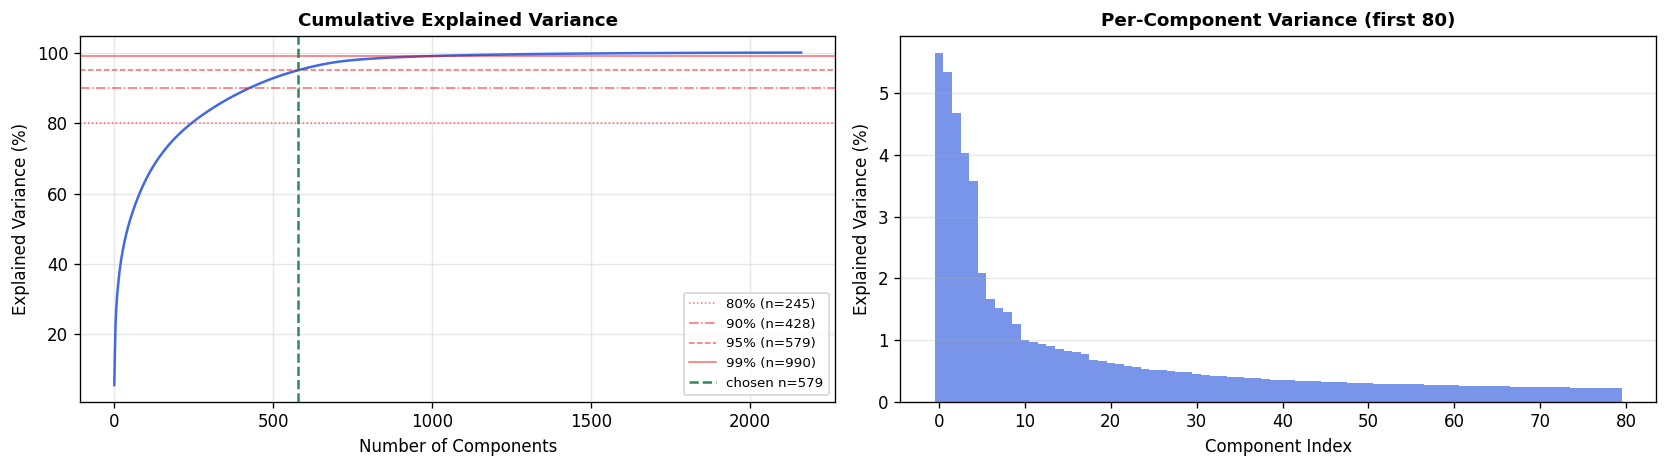

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.25, random_state=42, stratify=y_raw
)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_raw)
X_te_s = scaler.transform(X_te_raw)

# Probe full variance curve, no artificial ceiling
max_probe = min(X_tr_s.shape[0] - 1, X_tr_s.shape[1])
pca_probe = PCA(n_components=max_probe, random_state=42, svd_solver="full")
pca_probe.fit(X_tr_s)
cumvar = np.cumsum(pca_probe.explained_variance_ratio_) * 100

for t in [80, 90, 95, 99]:
    idx = int(np.searchsorted(cumvar, t)) + 1
    print(f"  {t}% variance → {idx} components")

# Let sklearn find exact cutoff via float n_components
pca = PCA(n_components=0.95, random_state=42, svd_solver="full")
X_tr = pca.fit_transform(X_tr_s)
X_te = pca.transform(X_te_s)

n_comp     = pca.n_components_
actual_var = float(np.sum(pca.explained_variance_ratio_)) * 100
print(f"\nPCA selected  : {n_comp} components")
print(f"Explained var : {actual_var:.2f}%")
print(f"X_tr: {X_tr.shape} | X_te: {X_te.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(cumvar, color="royalblue", lw=1.5)
for t, ls in zip([80, 90, 95, 99], [":", "-.", "--", "-"]):
    idx = int(np.searchsorted(cumvar, t)) + 1
    axes[0].axhline(t, color="red", linestyle=ls, lw=0.9, alpha=0.6, label=f"{t}% (n={idx})")
axes[0].axvline(n_comp, color="seagreen", linestyle="--", lw=1.5, label=f"chosen n={n_comp}")
axes[0].set_title("Cumulative Explained Variance", fontweight="bold")
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

n_show = min(80, len(pca_probe.explained_variance_ratio_))
axes[1].bar(range(n_show), pca_probe.explained_variance_ratio_[:n_show] * 100,
            color="royalblue", alpha=0.7, width=1.0)
axes[1].set_title(f"Per-Component Variance (first {n_show})", fontweight="bold")
axes[1].set_xlabel("Component Index")
axes[1].set_ylabel("Explained Variance (%)")
axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 17) Classification: Naive Bayes and Boosting Baselines

In [40]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np

# ── 1. SMOTE ───────────────────────────────────────────────────────────────
try:
    from imblearn.over_sampling import SMOTE
    min_class_count = int(pd.Series(y_tr).value_counts().min())
    k_neighbors = min(5, min_class_count - 1)
    if k_neighbors >= 1:
        sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_tr_bal, y_tr_bal = sm.fit_resample(X_tr, y_tr)
        print(f"SMOTE applied → {X_tr_bal.shape[0]} training samples")
        print(pd.Series(y_tr_bal).value_counts().to_string())
    else:
        raise ValueError("Not enough minority samples for SMOTE")
except Exception as e:
    print(f"SMOTE skipped ({e})")
    X_tr_bal, y_tr_bal = X_tr, y_tr

sw_bal = compute_sample_weight("balanced", y_tr_bal)

# ── 2. Gaussian Naive Bayes  ────────────────────────────────
print("\nFitting Naive Bayes …")
nb_clf = GaussianNB()
nb_clf.fit(X_tr_bal, y_tr_bal)
y_pred_nb = nb_clf.predict(X_te)

# ── 3. AdaBoost ───────────────────────────────────────
print("Fitting AdaBoost …")
ada_clf = AdaBoostClassifier(
    n_estimators=50, 
    learning_rate=0.5,
    random_state=42
)
ada_clf.fit(X_tr_bal, y_tr_bal)
y_pred_ada = ada_clf.predict(X_te)

# ── 4. Random Forest ───────────────────────────────────────
print("Fitting Random Forest …")
rf_clf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12,   
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_tr_bal, y_tr_bal)
y_pred_rf = rf_clf.predict(X_te)

# ── 5. SVM (primary fix — best for PCA-projected imbalanced data) ──────────
# SVM with RBF kernel + balanced class weight directly maximises the margin
# per class; it doesn't collapse to majority the way tree ensembles do when
# features are correlated or the boundary is non-linear.
print("Fitting SVM (this may take ~2–5 min) …")
svm_base = SVC(
    kernel="rbf",
    C=10,                       # controls margin softness; tune 1,10,100
    gamma="scale",              # sigma = 1 / (n_features * X.var())
    class_weight="balanced",    # penalises minority errors proportionally
    probability=True,           # needed for predict_proba + calibration
    random_state=42,
    max_iter=5000,
)
svm_base.fit(X_tr_bal, y_tr_bal)
y_pred_svm = svm_base.predict(X_te)

# ── 6. SVM with post-hoc threshold calibration ────────────────────────────
# Default argmax(proba) still biases toward majority. Dividing each class
# probability by its prior re-balances the decision surface at inference time.
proba_svm = svm_base.predict_proba(X_te)
class_priors = np.bincount(y_tr_bal) / len(y_tr_bal)     # uniform after SMOTE
# Posterior ∝ likelihood → divide by prior to get likelihood-ratio score
adjusted = proba_svm / (class_priors + 1e-10)
y_pred_svm_cal = np.argmax(adjusted, axis=1)

# ── 7. Summary table ──────────────────────────────────────────────────────
results = [
    ("Naive Bayes",           y_pred_nb),
    ("AdaBoost",              y_pred_ada),
    ("Random Forest",         y_pred_rf),
    ("SVM (argmax)",          y_pred_svm),
    ("SVM (calibrated thr)",  y_pred_svm_cal),
]

rows = []
for name, preds in results:
    rows.append({
        "Model":    name,
        "Accuracy": accuracy_score(y_te, preds),
        "F1 macro": f1_score(y_te, preds, average="macro", zero_division=0),
        "F1 weighted": f1_score(y_te, preds, average="weighted", zero_division=0),
    })

model_table = pd.DataFrame(rows)
print("\n" + model_table.round(4).to_string(index=False))

# Pick best by macro-F1 (fairer than accuracy for imbalanced data)
best_idx   = model_table["F1 macro"].idxmax()
best_name  = model_table.loc[best_idx, "Model"]
best_pred  = dict(results)[best_name]
best_model = svm_base   # SVM used for predict_proba in pipeline

# Map name → predict function (handles calibrated threshold variant)
def best_predict(X):
    if "calibrated" in best_name:
        p = svm_base.predict_proba(X)
        return np.argmax(p / (class_priors + 1e-10), axis=1)
    return dict({
        "Naive Bayes":          nb_clf,
        "AdaBoost":             ada_clf,
        "Random Forest":        rf_clf,
        "SVM (argmax)":         svm_base,
    }).get(best_name, svm_base).predict(X)

print(f"\nBest model (by macro-F1): {best_name}")

SMOTE applied → 25140 training samples
0    5028
3    5028
1    5028
2    5028
4    5028

Fitting Naive Bayes …
Fitting AdaBoost …
Fitting Random Forest …
Fitting SVM (this may take ~2–5 min) …

               Model  Accuracy  F1 macro  F1 weighted
         Naive Bayes    0.5336    0.2180       0.5174
            AdaBoost    0.5148    0.2994       0.5666
       Random Forest    0.7078    0.3820       0.6701
        SVM (argmax)    0.7648    0.4999       0.7383
SVM (calibrated thr)    0.7447    0.4045       0.6928

Best model (by macro-F1): SVM (argmax)


## 18) Model Evaluation: Accuracy, Precision, Recall, F1, Confusion Matrix


  Best model : SVM (argmax)
  accuracy                 :  76.48 %
  precision_macro          :  57.64 %
  recall_macro             :  45.72 %
  f1_macro                 :  49.99 %
  precision_weighted       :  73.18 %
  recall_weighted          :  76.48 %
  f1_weighted              :  73.83 %

                      precision    recall  f1-score   support

   Actinic Keratosis       0.49      0.32      0.39        82
Basal Cell Carcinoma       0.48      0.31      0.38       128
    Benign Keratosis       0.54      0.37      0.44       275
   Melanocytic Nevus       0.82      0.96      0.89      1677
            Melanoma       0.55      0.33      0.41       278

            accuracy                           0.76      2440
           macro avg       0.58      0.46      0.50      2440
        weighted avg       0.73      0.76      0.74      2440



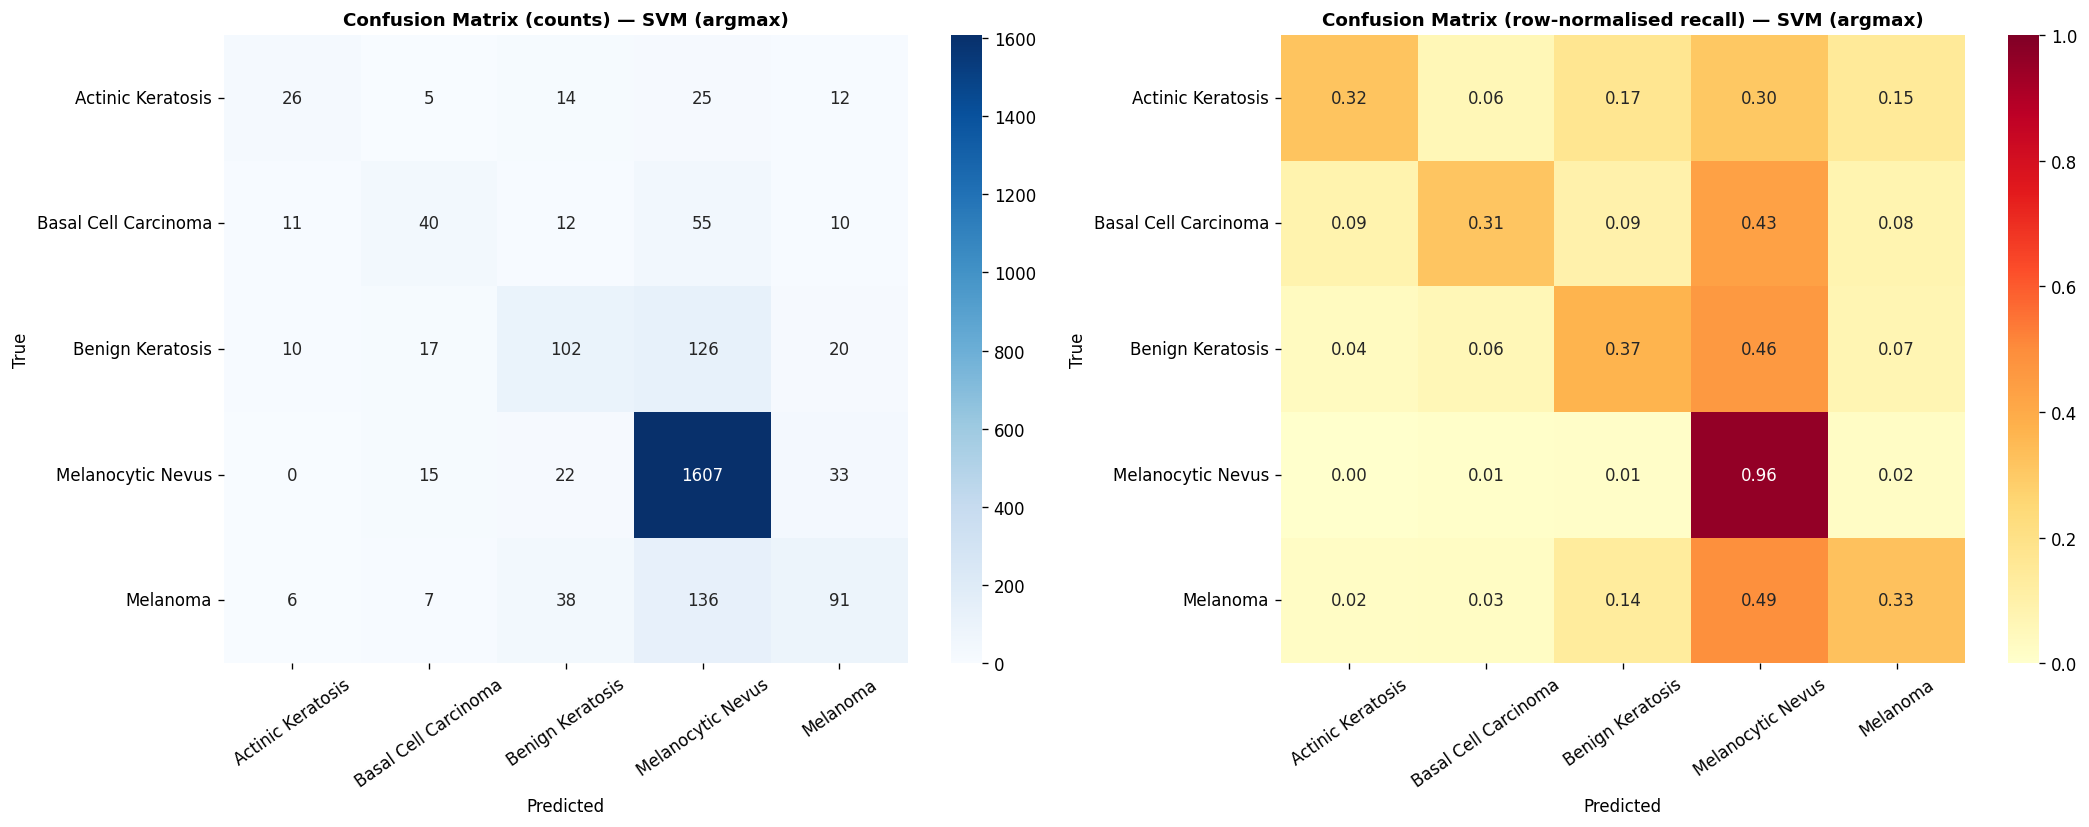

               Class  Support  Precision  Recall    F1
   Melanocytic Nevus     1677      0.825   0.958 0.886
            Melanoma      278      0.548   0.327 0.410
    Benign Keratosis      275      0.543   0.371 0.441
Basal Cell Carcinoma      128      0.476   0.312 0.377
   Actinic Keratosis       82      0.491   0.317 0.385


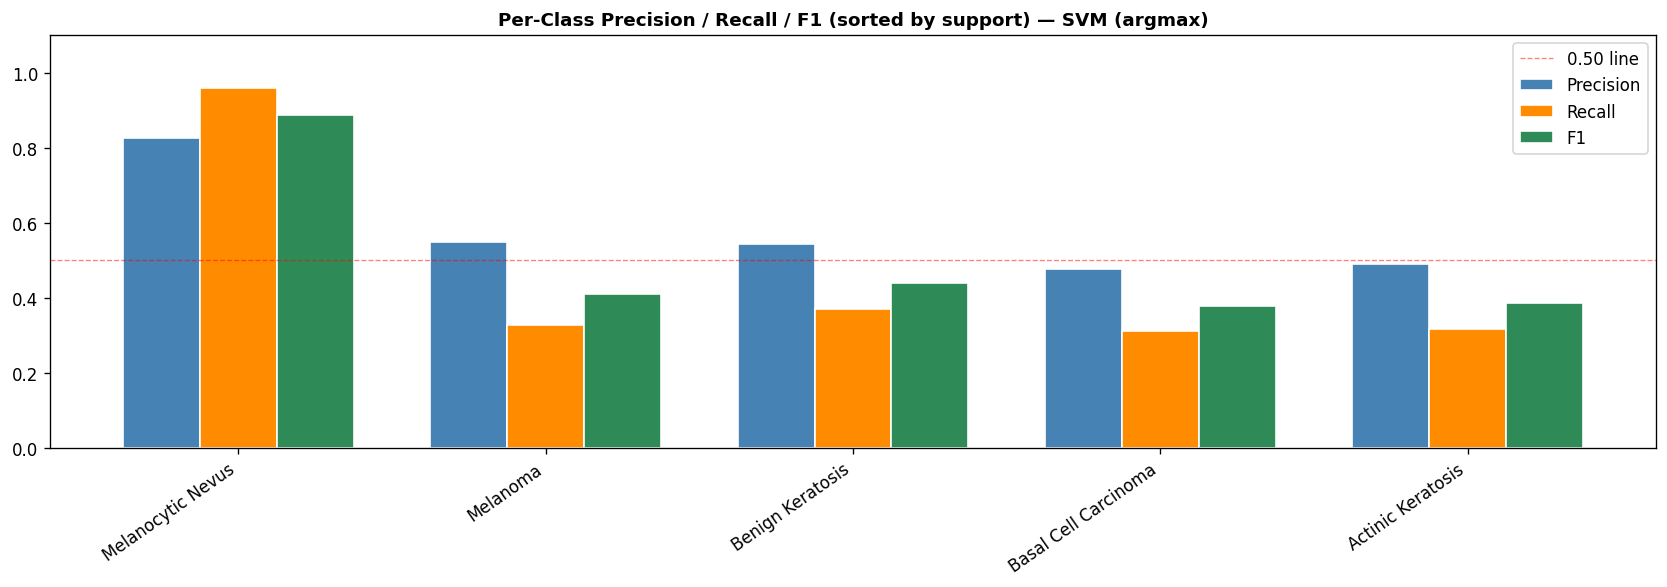


All-model comparison (sorted by macro-F1):
               Model  Accuracy  F1 macro
        SVM (argmax)    0.7648    0.4999
SVM (calibrated thr)    0.7447    0.4045
       Random Forest    0.7078    0.3820
            AdaBoost    0.5148    0.2994
         Naive Bayes    0.5336    0.2180


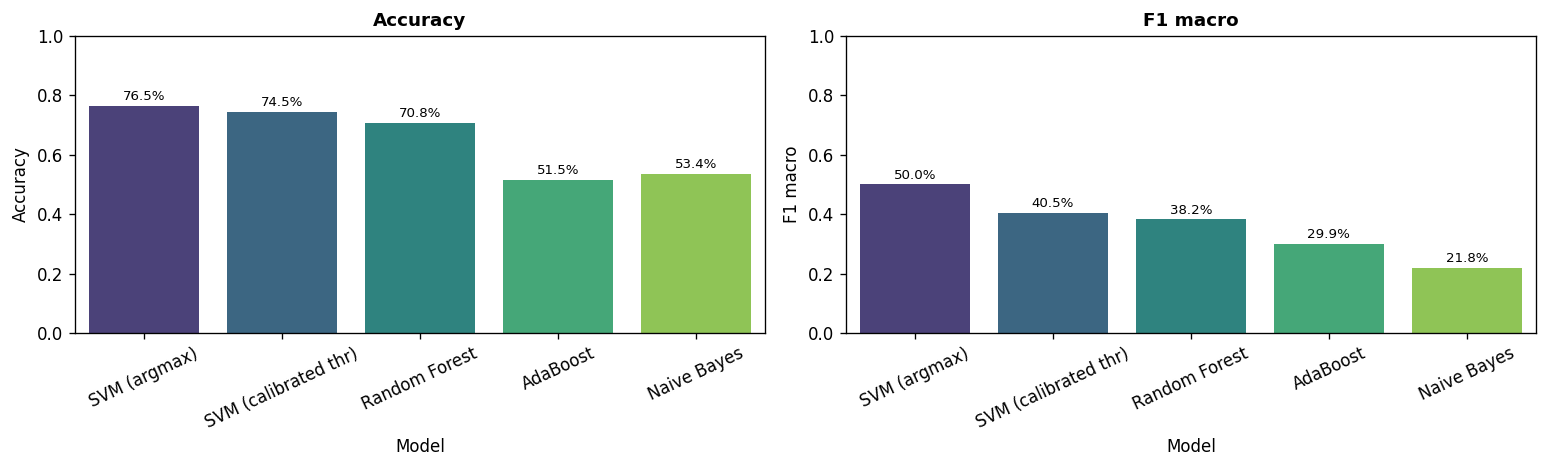

In [41]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ── Overall metrics ────────────────────────────────────────────────────────
eval_metrics = {
    "accuracy":           accuracy_score(y_te, best_pred),
    "precision_macro":    precision_score(y_te, best_pred, average="macro",    zero_division=0),
    "recall_macro":       recall_score(   y_te, best_pred, average="macro",    zero_division=0),
    "f1_macro":           f1_score(       y_te, best_pred, average="macro",    zero_division=0),
    "precision_weighted": precision_score(y_te, best_pred, average="weighted", zero_division=0),
    "recall_weighted":    recall_score(   y_te, best_pred, average="weighted", zero_division=0),
    "f1_weighted":        f1_score(       y_te, best_pred, average="weighted", zero_division=0),
}
print(f"\n{'='*55}")
print(f"  Best model : {best_name}")
print(f"{'='*55}")
for k, v in eval_metrics.items():
    print(f"  {k:<25s}: {v*100:6.2f} %")
print(f"{'='*55}\n")
print(classification_report(y_te, best_pred, target_names=le.classes_, zero_division=0))

# ── Dual confusion matrix ─────────────────────────────────────────────────
cm      = confusion_matrix(y_te, best_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f"Confusion Matrix (counts) — {best_name}", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=35); axes[0].tick_params(axis="y", rotation=0)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title(f"Confusion Matrix (row-normalised recall) — {best_name}", fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=35); axes[1].tick_params(axis="y", rotation=0)
plt.tight_layout(); plt.show()

# ── Per-class bar chart ────────────────────────────────────────────────────
per_p   = precision_score(y_te, best_pred, average=None, zero_division=0)
per_r   = recall_score(   y_te, best_pred, average=None, zero_division=0)
per_f   = f1_score(       y_te, best_pred, average=None, zero_division=0)
support = np.bincount(y_te, minlength=len(le.classes_))
order   = np.argsort(support)[::-1]

class_df = pd.DataFrame({
    "Class":     [le.classes_[i] for i in order],
    "Support":   support[order],
    "Precision": per_p[order],
    "Recall":    per_r[order],
    "F1":        per_f[order],
})
print(class_df.round(3).to_string(index=False))

x, w = np.arange(len(le.classes_)), 0.25
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w, per_p[order], w, label="Precision",  color="steelblue",  edgecolor="white")
ax.bar(x,     per_r[order], w, label="Recall",     color="darkorange", edgecolor="white")
ax.bar(x + w, per_f[order], w, label="F1",         color="seagreen",   edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([le.classes_[i] for i in order], rotation=35, ha="right")
ax.set_ylim(0, 1.10)
ax.axhline(0.5, color="red", lw=0.8, linestyle="--", alpha=0.5, label="0.50 line")
ax.legend()
ax.set_title(f"Per-Class Precision / Recall / F1 (sorted by support) — {best_name}", fontweight="bold")
plt.tight_layout(); plt.show()

# ── All-model macro-F1 comparison ─────────────────────────────────────────
all_results = [
    ("Naive Bayes",          y_pred_nb),
    ("AdaBoost",             y_pred_ada),
    ("Random Forest",        y_pred_rf),
    ("SVM (argmax)",         y_pred_svm),
    ("SVM (calibrated thr)", y_pred_svm_cal),
]
compare_df = pd.DataFrame([{
    "Model":    n,
    "Accuracy": accuracy_score(y_te, p),
    "F1 macro": f1_score(y_te, p, average="macro", zero_division=0),
} for n, p in all_results]).sort_values("F1 macro", ascending=False)

print("\nAll-model comparison (sorted by macro-F1):")
print(compare_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ["Accuracy", "F1 macro"]):
    bars = sns.barplot(data=compare_df, x="Model", y=metric, ax=ax,
                       palette="viridis", order=compare_df["Model"])
    ax.set_ylim(0, 1); ax.set_title(metric, fontweight="bold")
    ax.tick_params(axis="x", rotation=25)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height()*100:.1f}%", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()